# Speed Dating Analysis
## What Makes People Match?

This project analyzes a speed dating experiment conducted at Columbia University between 2002 and 2004. Over 21 waves, participants met a series of potential partners in 4-minute dates and decided whether they would like to see each person again. A match occurs when both participants say yes.

The dataset is rich: before the event, participants filled out surveys about their demographics, lifestyle, activities, and what they look for in a partner. During the event, they rated each date on 6 attributes (attractiveness, sincerity, intelligence, fun, ambition, shared interests). Follow-up surveys were collected the next day and 3-4 weeks later.

Our goal: understand what makes two people match 

To answer this, we combine exploratory analysis (preferences by gender, activity profiles, field of study) with machine learning (Logistic Regression, Random Forest, XGBoost, LightGBM, KNN, Stacking) and interpretability tools (SHAP, decision trees).


# 1. data processing
## 1.1. Dataset Overview

In [ ]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import math
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from dotenv import load_dotenv
import os
import ollama
import json, re
import ast, re
import json
from sklearn.model_selection import train_test_split, cross_val_score
import joblib, os
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import optuna
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
from xgboost import plot_tree
import matplotlib.pyplot as plt
import umap
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from lightgbm import plot_tree
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier


In [2]:
# The file is not encoded in UTF-8, so it is converted to Latin-1.
df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin-1')

In [3]:
df.columns.tolist()

['iid',
 'id',
 'gender',
 'idg',
 'condtn',
 'wave',
 'round',
 'position',
 'positin1',
 'order',
 'partner',
 'pid',
 'match',
 'int_corr',
 'samerace',
 'age_o',
 'race_o',
 'pf_o_att',
 'pf_o_sin',
 'pf_o_int',
 'pf_o_fun',
 'pf_o_amb',
 'pf_o_sha',
 'dec_o',
 'attr_o',
 'sinc_o',
 'intel_o',
 'fun_o',
 'amb_o',
 'shar_o',
 'like_o',
 'prob_o',
 'met_o',
 'age',
 'field',
 'field_cd',
 'undergra',
 'mn_sat',
 'tuition',
 'race',
 'imprace',
 'imprelig',
 'from',
 'zipcode',
 'income',
 'goal',
 'date',
 'go_out',
 'career',
 'career_c',
 'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga',
 'exphappy',
 'expnum',
 'attr1_1',
 'sinc1_1',
 'intel1_1',
 'fun1_1',
 'amb1_1',
 'shar1_1',
 'attr4_1',
 'sinc4_1',
 'intel4_1',
 'fun4_1',
 'amb4_1',
 'shar4_1',
 'attr2_1',
 'sinc2_1',
 'intel2_1',
 'fun2_1',
 'amb2_1',
 'shar2_1',
 'attr3_1',
 'sinc3_1',
 

In [4]:
df.head(10)

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
5,1,1.0,0,1,1,1,10,7,NaN,6,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
6,1,1.0,0,1,1,1,10,7,NaN,1,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
7,1,1.0,0,1,1,1,10,7,NaN,2,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
8,1,1.0,0,1,1,1,10,7,NaN,8,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
9,1,1.0,0,1,1,1,10,7,NaN,9,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [5]:
display(df.shape)

(8378, 195)

# 1.2 Isolation 

First, we group related columns together to make them easier to handle

- **background variables**: regarding the identification of participants, their interests, and their demographic data 
- **feedback variables** : Regarding their feedback on dates and matches 
-  **Time-dependent responses** : their answers for each question, sorted by time 

In [6]:
# --- Isolation of background variables ---
# Identifiers: 
identifiers = ['iid', 'id', 'idg', 'gender', 'wave', 'round', 'position', 'positin1', 'order', 'condtn']

# partner information: 
partner = ['age_o', 'race_o', 'samerace', 'int_corr']

# Stated preferences by time
stated_preferences_t1 = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
stated_preferences_th = ['attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s']
stated_preferences_t2 = ['attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2']
stated_preferences_t3 = ['attr1_3', 'sinc1_3', 'intel1_3', 'fun1_3', 'amb1_3', 'shar1_3']

# scorecard : Filled out by subjects after each "date" during the event
scorecard = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'met']
scorecard_partner = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o']
preferences_partner = ['pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha']

# Demographic and social information: 
demographics = ['age','field_cd', 'race', 'imprace', 'imprelig', 'from', 'zipcode']
social_level = ['from', 'mn_sat', 'field', 'field_cd', 'career', 'career_c', 'undergrd' ]
standard_living = ['income', 'zipcode', 'tuition']

# goal and habits: 
goal_habits = ['goal', 'date', 'go_out', 'exphappy', 'expnum']

# activities: 
activities = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art','hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater','movies', 'concerts', 'music', 'shopping', 'yoga']


# --- Isolation of feed-back variables ---
# match variables 
match_during_event = ['partner', 'pid', 'match', 'dec', 'dec_o', 'match_es']

# Satisfaction post-event: 
satisfaction_post_event = ['satis_2', 'length', 'numdat_2']

# match tracking after 4 weeks 
match_follow_up = ['you_call', 'them_cal', 'date_3', 'numdat_3', 'num_in_3']

In [7]:
# --- Isolation of responses for each question for each time --- 
# question documentation
QUESTIONS = {
    'q1' : 'What are you looking for in the opposite sex?',
    'q2' : 'What do you think the opposite sex looks for in a date?',
    'q3' : 'How do you think you measure up?',
    'q4' : 'What do you think MOST of your fellow men/women look for in the opposite sex?',
    'q5' : 'How do you think others perceive you?',
    'q6' : 'How important were these attributes during the date?'
}

# TIME 01 : Sign-up Survey = 
time_01 = {
    'q1' : ['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1'],
    'q2' : ['attr2_1','sinc2_1','intel2_1','fun2_1','amb2_1','shar2_1'],
    'q3' : ['attr3_1','sinc3_1','fun3_1','intel3_1','amb3_1',],
    'q4' : ['attr4_1','sinc4_1','intel4_1','fun4_1','amb4_1','shar4_1'],
    'q5' : ['attr5_1','sinc5_1','intel5_1','fun5_1','amb5_1'],
}

# TIME 01_bis : Half way through meeting
time_halfway = {
    'q1' : ['attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s'],
    'q3' : ['attr3_s', 'sinc3_s', 'intel3_s', 'fun3_s', 'amb3_s']
}

# TIME 02 : the next day
time_02 = {    
    'q1' : ['attr1_2','sinc1_2','intel1_2','fun1_2','amb1_2','shar1_2'],
    'q2' : ['attr2_2','sinc2_2','intel2_2','fun2_2','amb2_2','shar2_2'],
    'q3' : ['attr3_2','sinc3_2','fun3_2','intel3_2','amb3_2',],
    'q4' : ['attr4_2','sinc4_2','intel4_2','fun4_2','amb4_2','shar4_2'],
    'q5' : ['attr5_2','sinc5_2','intel5_2','fun5_2','amb5_2'],
    'q6' : ['attr7_2','sinc7_2','intel7_2','fun7_2','amb7_2','shar7_2']
}

# TIME 03 : 3 or 4 weeks later
time_03 = {    
    'q1' : ['attr1_3','sinc1_3','intel1_3','fun1_3','amb1_3','shar1_3'],
    'q2' : ['attr2_3','sinc2_3','intel2_3','fun2_3','amb2_3','shar2_3'],
    'q3' : ['attr3_3','sinc3_3','fun3_3','intel3_3','amb3_3',],
    'q4' : ['attr4_3','sinc4_3','intel4_3','fun4_3','amb4_3','shar4_3'],
    'q5' : ['attr5_3','sinc5_3','intel5_3','fun5_3','amb5_3'],
    'q6' : ['attr7_3','sinc7_3','intel7_3','fun7_3','amb7_3','shar7_3']
}

# Master dictionary grouping all time periods
ALL_RESPONSES = {
    'time_01' : time_01,
    'time_halfway' : time_halfway,
    'time_02' : time_02,
    'time_03' : time_03
}

# 1.3. Mask creation 
creation of masks to facilitate main selections 

In [8]:
# Gender 
female = df['gender'] == 0 
male = df['gender'] == 1 

# Matchs 
matchs_yes = df['match'] == 1 
matchs_no = df['match'] == 0
matchs_real = df['date_3'] == 1 
matchs_real_number = (df['numdat_3'] == 1) & (df['num_in_3'])
matchs_call = (df['you_call'] > 0) | (df['them_cal'] > 0)
partner_yes = df['dec_o'] == 1 
rejected = (df['dec'] == 1) & (df['dec_o'] == 0)
rejector = (df['dec'] == 0) & (df['dec_o'] == 1)

# Age 
young = df['age'] < 25
middle_age = (df['age'] >= 25) & (df['age'] < 32) # personal choice: Recent studies show that the brain truly stabilizes at age 32. 
adult= (df['age'] >= 32) & (df['age'] < 42)
older = (df['age'] >= 42)

# Career 
art = df['career'].isin([6, 17])
literary = df['career'].isin([1, 13, 16])
social = df['career'].isin([3, 4, 11, 12, 9])
business = df['career'].isin([7, 8])
science = df['career'][5]
sport = df['career'][14]
university = df['career'][2]
other = df['career'].isin([10, 15])

# Goal 
goal_fun = df['goal'] == 1 
goal_meet = df['goal'] == 2
goal_date = df['goal'] == 3
goal_serious = df['goal'] == 4
goal_action = df['goal'] == 5
goal_other = df['goal'] == 6     

# dating habits
date_often = df['date'].isin([1, 2, 3])
date_rarely = df['date'].isin([1, 2, 3])

# condition of experiment 
limited_choice = df['condtn'] == 1 
extensive_choice = df['condtn'] == 2 

# satisfaction 
satisfied = df['satis_2'] >= 5 
unsatisfied = df['satis_2'] < 5 

In [9]:
display(df['age'].max())

55.0

# 1.4. Normalization 

Groups 6 to 9 have different scorecards; they had to score from 1 to 10 rather than with a limited number of 100 points like the other groups.

- First: observe the differences between waves 6 to 9 and the others.
- If the differences are negligible: normalize the data.
- At the same time, we will take the opportunity to create a function that will allow us to analyze the answers to the questions according to the selected groups and masks. This will greatly simplify the work that follows.


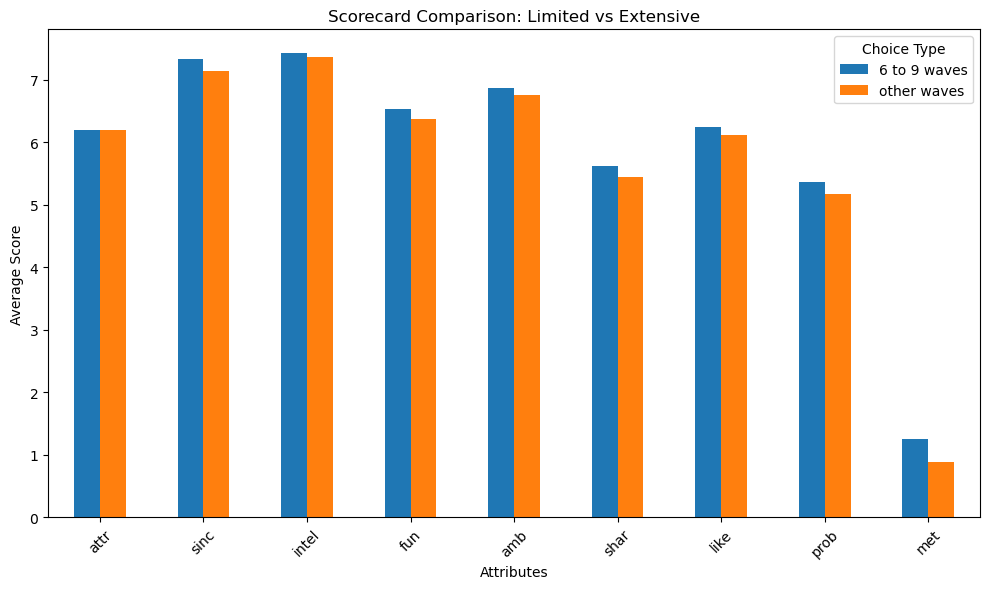

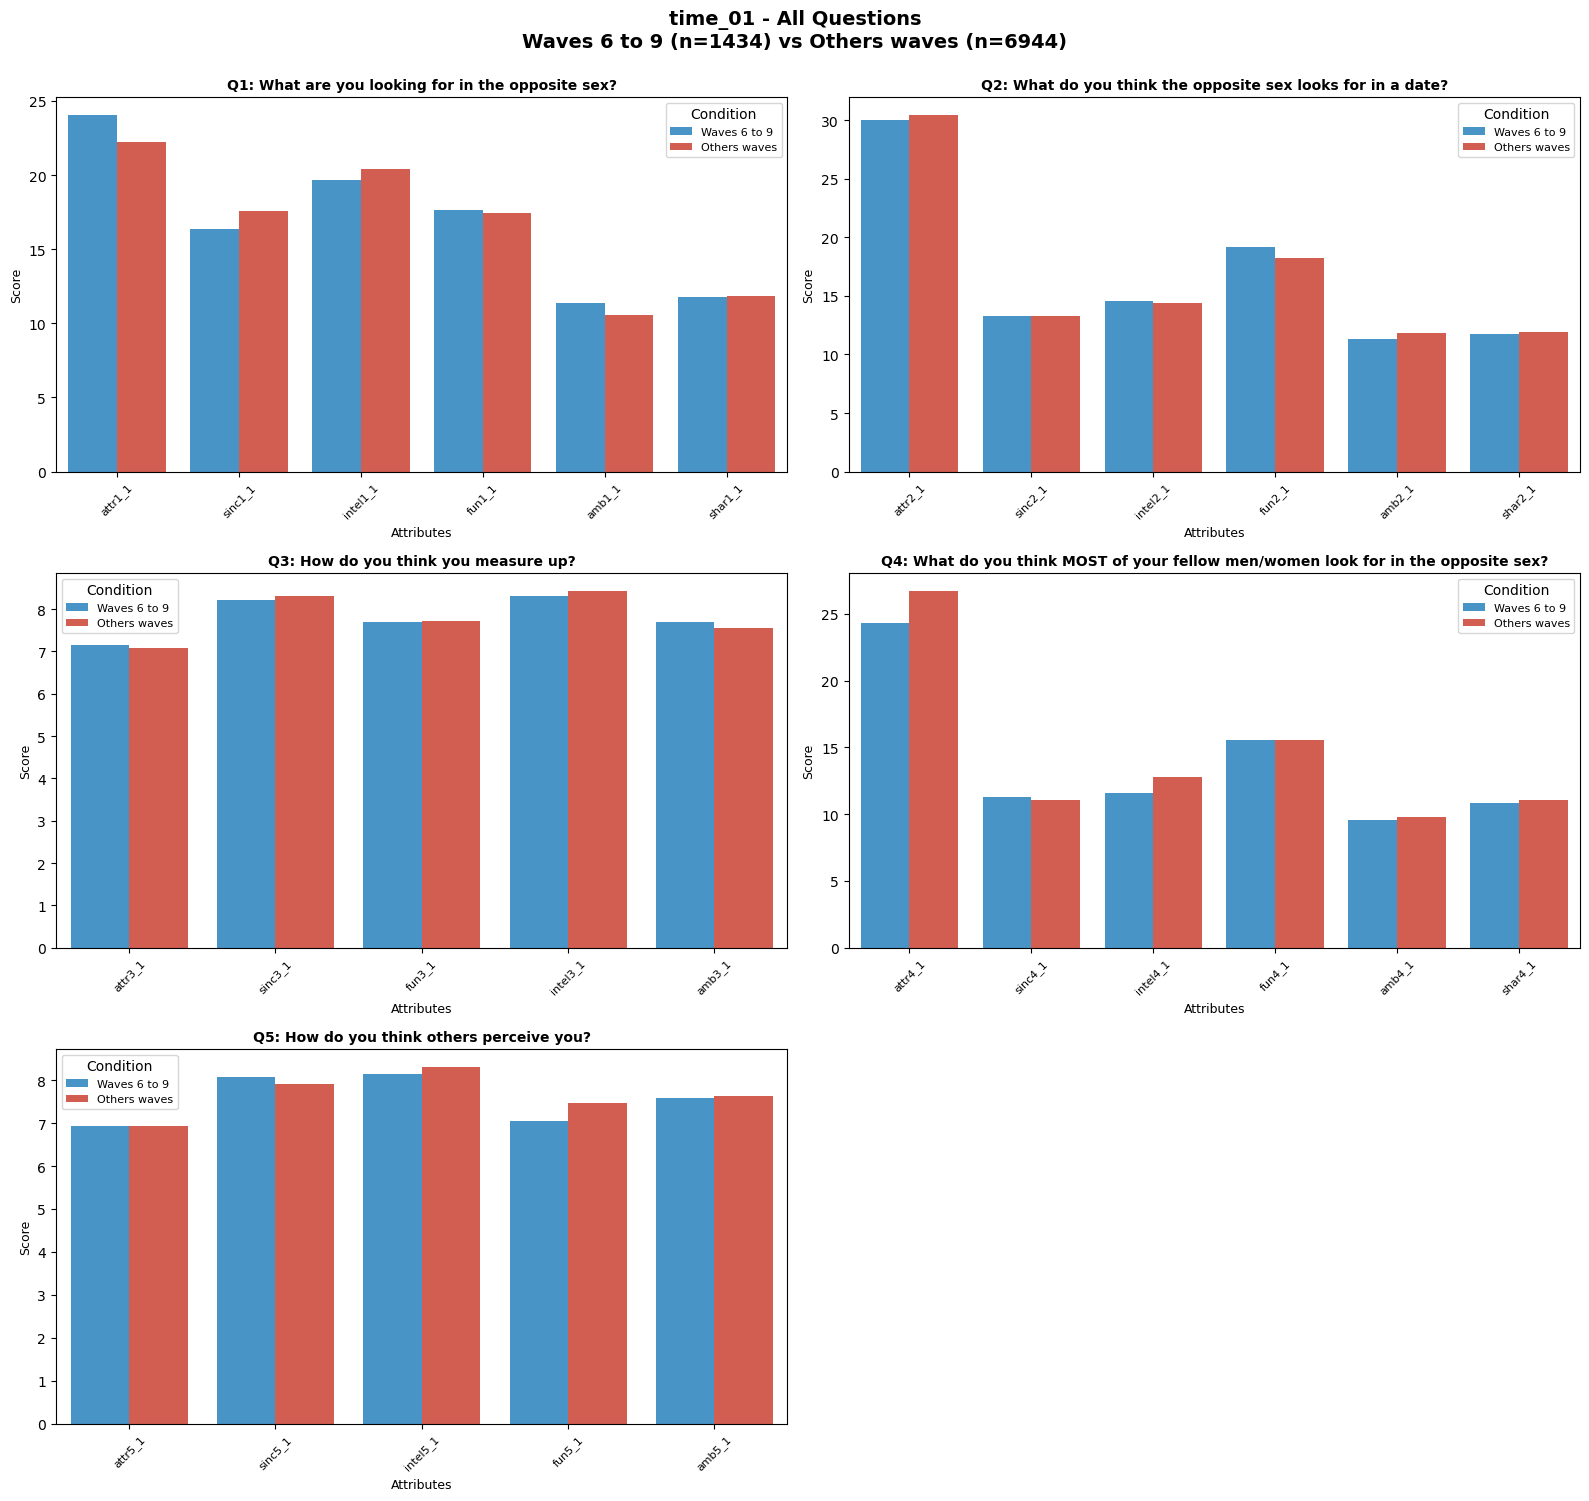

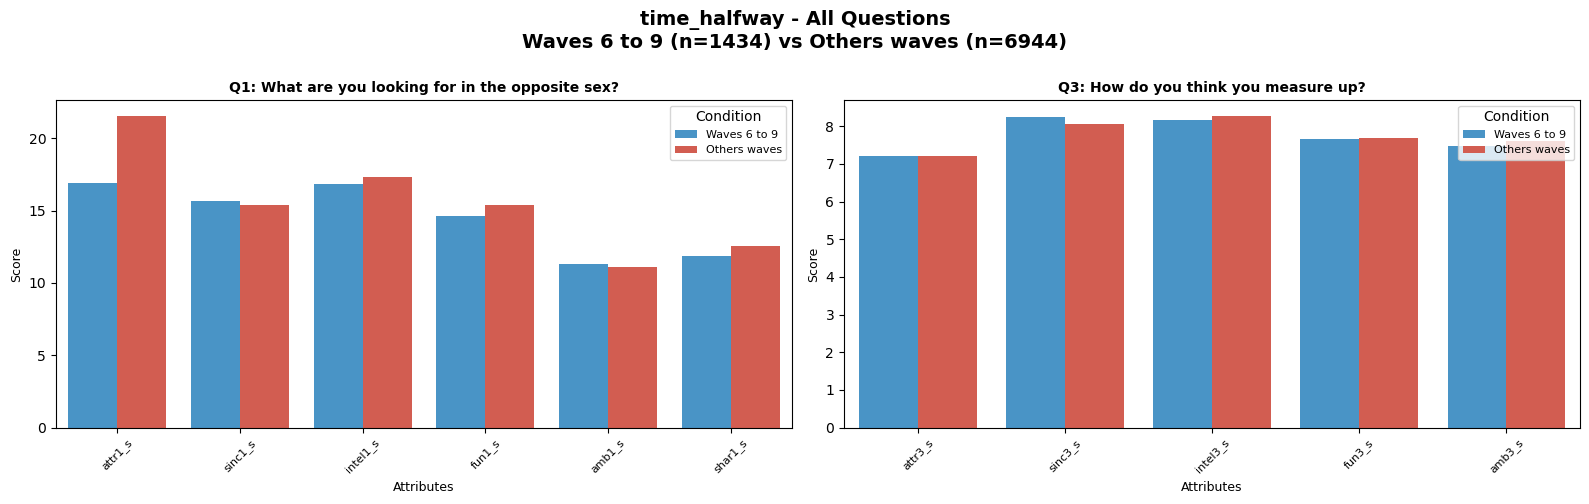

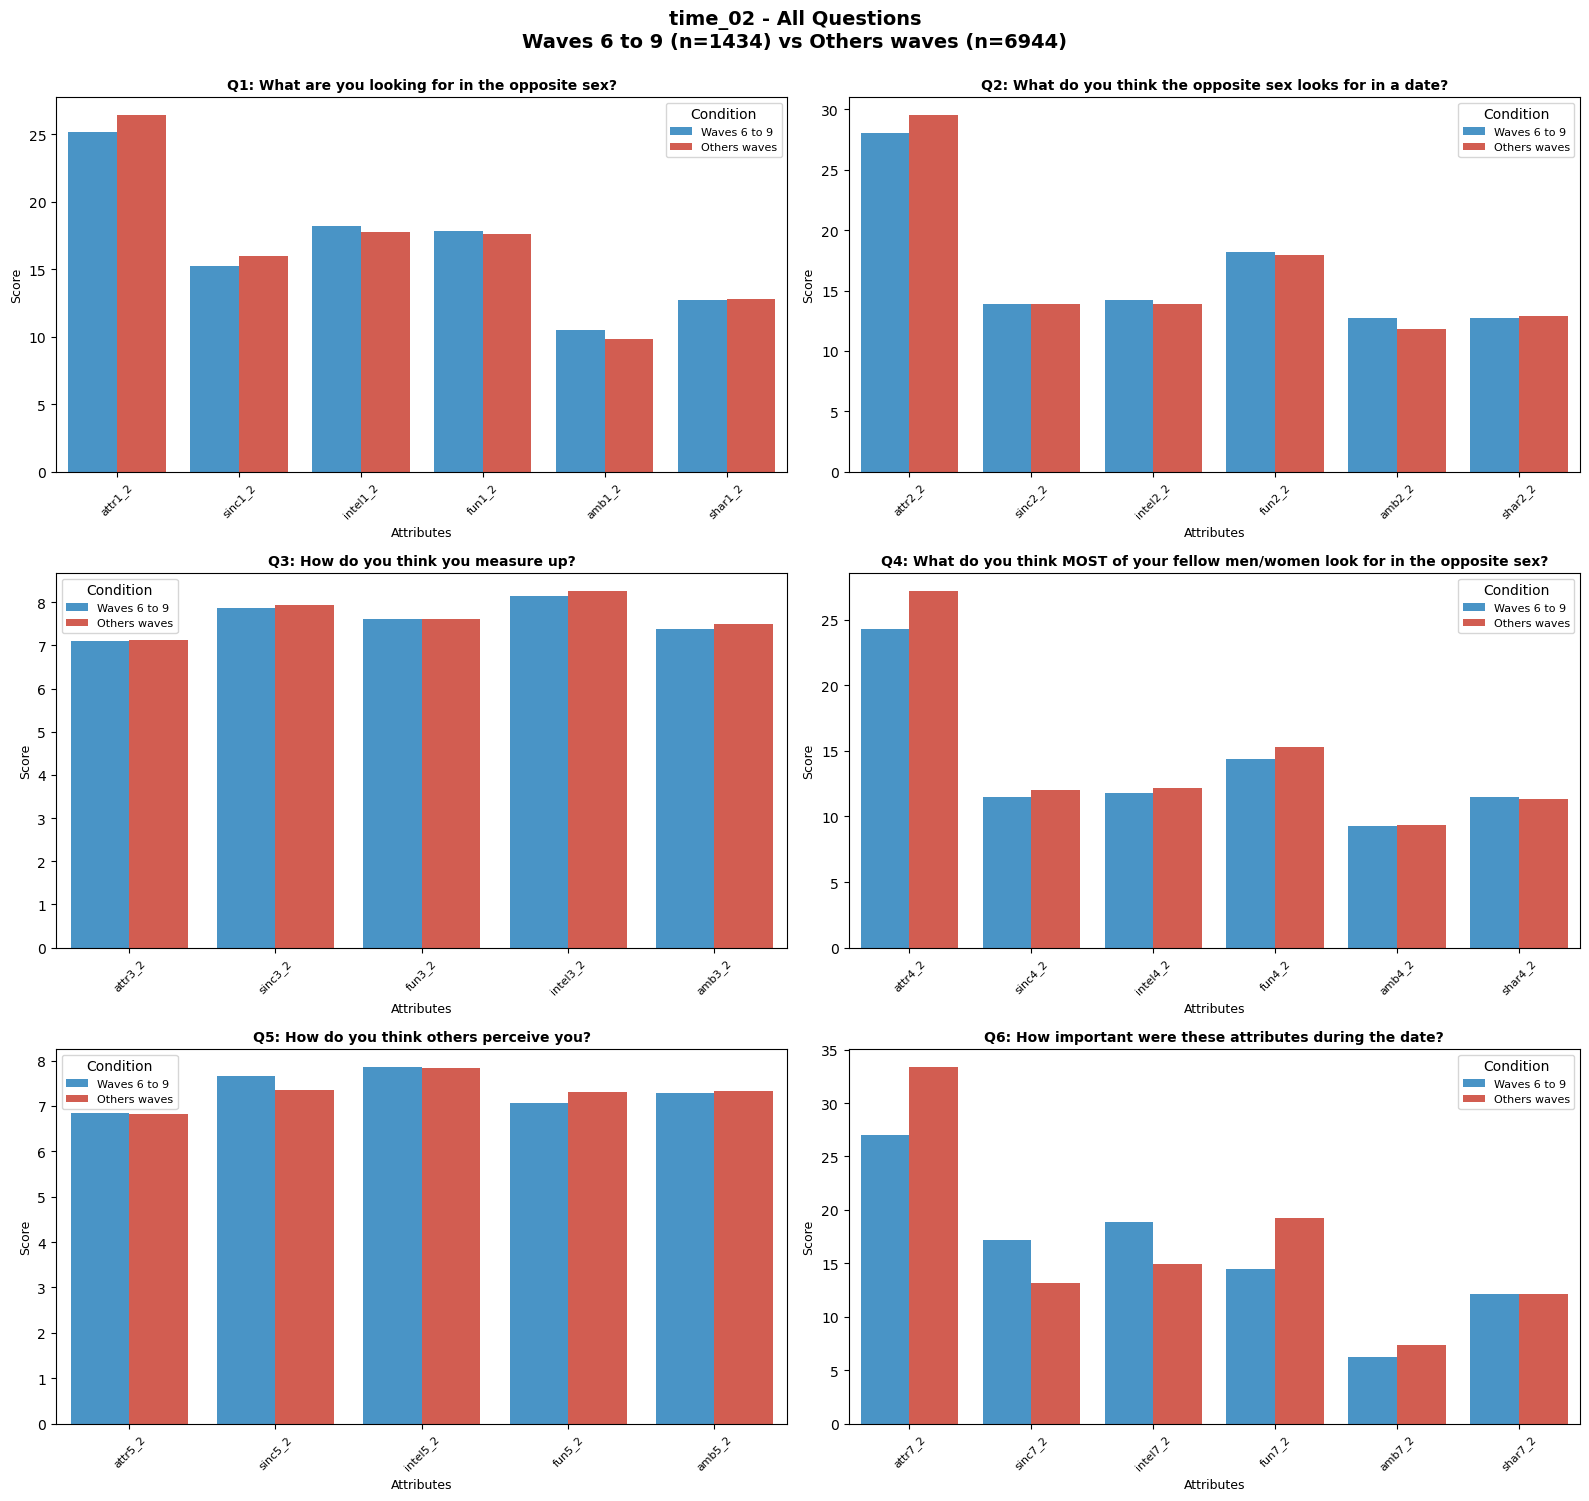

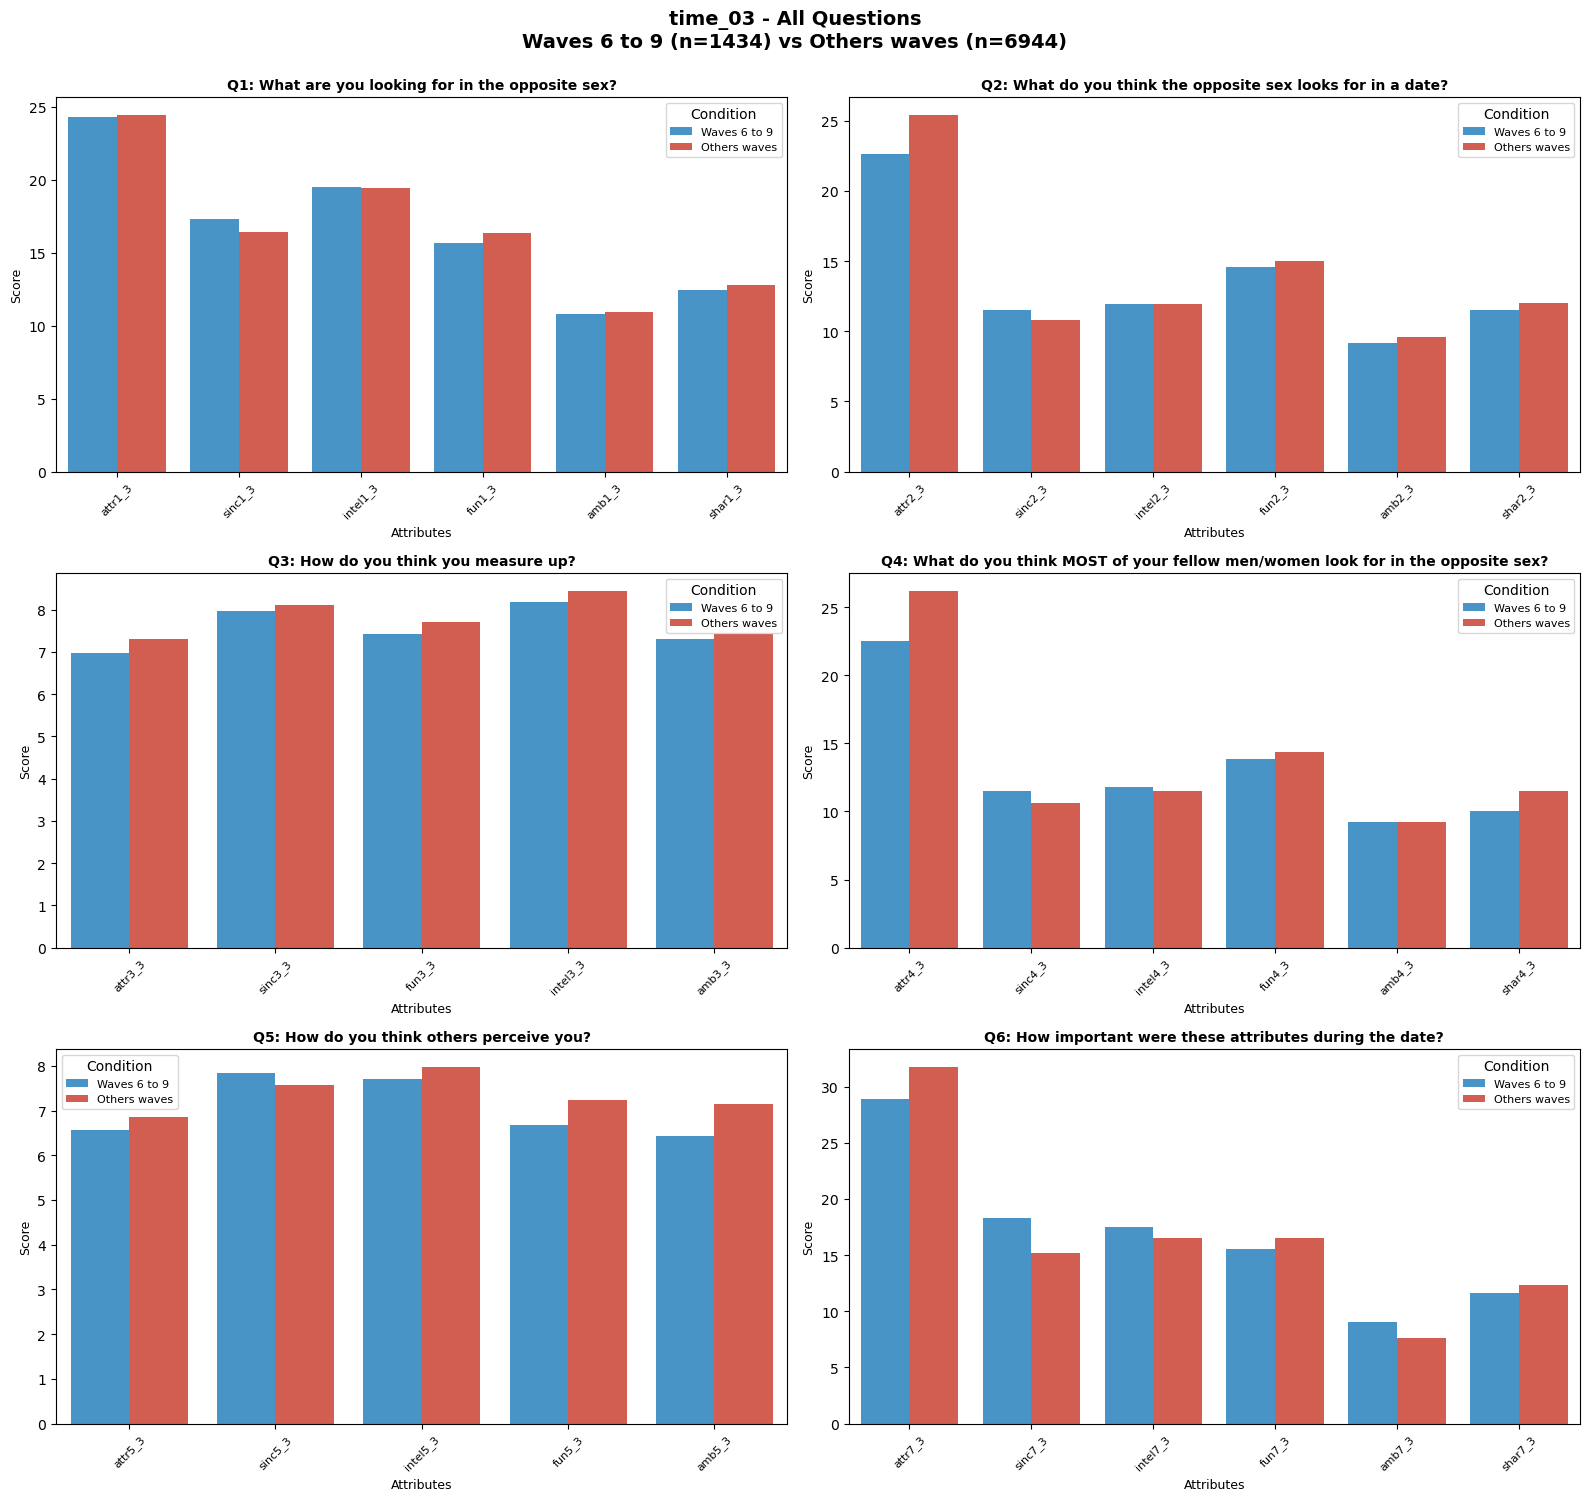

The differences between the two groups are not very marked.  
It can be observed that when people have complete freedom to allocate their points,
they tend to give more importance to physical attraction. However, in both groups, 
this criterion is present in the same proportion compared to the others. 
The differences between waves 6 to 9 and the others are therefore not really significant.
---
We therefore have a clear path to normalize the data for waves 6 to 9.


In [10]:
# --- Verification of a significant difference between 6 to 9 and the others  --- 
# verification between scorecards 
scorecard_limited_choice = df.loc[limited_choice, scorecard].mean()
scorecard_extensive_choice = df.loc[extensive_choice, scorecard].mean()
comparison_choice_wave = pd.DataFrame({
    '6 to 9 waves' : scorecard_limited_choice,
    'other waves' : scorecard_extensive_choice 
})
# comparison chart between the scorecards for waves 6 to 9 and the others 
comparison_choice_wave.plot(kind='bar', figsize=(10, 6))
plt.title('Scorecard Comparison: Limited vs Extensive')
plt.xlabel('Attributes')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Choice Type')
plt.tight_layout()
plt.show()


# verification between questionnaires  
# Creation of generical function for simplify next graph generation
def compare_time(time_name, mask_01, mask_02, graph_name_01, graph_name_02, aggregation='mean'):
    """Comparison of the two groups for all questionnaires answers"""
    # recovery of the dictionary for this time 
    time_dictionary = ALL_RESPONSES[time_name]

    # creation of a grid to display multiple graphs at the same time 
    n_questions = len(time_dictionary)
    ncols = 2
    nrows = math.ceil(n_questions / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
    # Converting “axes” into an array list
    if n_questions == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Aggregation and visualization
    for index, (dictionary_keys, dictionary_values) in enumerate(time_dictionary.items()):
        aggregation_01 = df.loc[mask_01, dictionary_values].agg(aggregation)
        aggregation_02 = df.loc[mask_02, dictionary_values].agg(aggregation)
        # DataFrame with aggregation
        comparison_group = pd.DataFrame({
            graph_name_01: aggregation_01,
            graph_name_02: aggregation_02
        })
        # visualization of the dataframe with seaborn
        comparison_long = comparison_group.reset_index().melt( id_vars='index',
        var_name='Condition', value_name='Score')
        comparison_long.rename(columns={'index': 'Attribute'}, inplace=True)
        sns.barplot(data=comparison_long, x='Attribute', y='Score', hue='Condition',
                    palette=['#3498db', '#e74c3c'], ax=axes[index])
        axes[index].set_title(f'{dictionary_keys.upper()}: {QUESTIONS[dictionary_keys]}',
            fontsize=10, fontweight='bold')
        axes[index].set_xlabel('Attributes', fontsize=9)
        axes[index].set_ylabel('Score', fontsize=9)
        axes[index].tick_params(axis='x', rotation=45, labelsize=8)
        axes[index].legend(title='Condition', fontsize=8)
    # hide empty charts 
    for idx in range(n_questions, len(axes)):
        axes[idx].set_visible(False) 
    # Title
    plt.suptitle(
        f'{time_name} - All Questions\n'
        f'{graph_name_01} (n={mask_01.sum()}) vs {graph_name_02} (n={mask_02.sum()})', 
        fontsize=14,
        fontweight='bold',
        y=0.998
    )
    plt.tight_layout()
    plt.show()


# and creation of a child function for all times
def compare_all_times(mask_01, mask_02, graph_name_01, graph_name_02, aggregation='mean'):
    """comparison two groups between all times"""
    for time_name in ALL_RESPONSES.keys():
        compare_time(time_name, mask_01, mask_02, graph_name_01, graph_name_02, aggregation)



"""Here we go ! We can finally enjoy the simplicity offered
by these functions to display all graphs."""
compare_all_times(limited_choice, extensive_choice, 'Waves 6 to 9', 'Others waves') # My plaesure.


# Comment
print("""The differences between the two groups are not very marked.  
It can be observed that when people have complete freedom to allocate their points,
they tend to give more importance to physical attraction. However, in both groups, 
this criterion is present in the same proportion compared to the others. 
The differences between waves 6 to 9 and the others are therefore not really significant.""")
print('---')
print('We therefore have a clear path to normalize the data for waves 6 to 9.')

In [11]:
# --- Normalization of wave 6 to 9 --- 
# Addition of all questionnaires 
questionnaire_columns = []
for questionnaire in ALL_RESPONSES.values():
    for question_vars in questionnaire.values():
        questionnaire_columns.extend(question_vars)

# grouping with scorecards
columns_to_normalize = (
    scorecard +
    scorecard_partner +
    preferences_partner + 
    questionnaire_columns
)

# normalization 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# 1.5 Simplification of work

Now let's simplify things and combine our groups and masks into a single table. This will allow us to see them all at a glance. The rest will be much easier.

In [12]:
# --- Simplification of futur work ---
# creation of a column for groups
group_names = [
    'Identifiers', 'Partner Info', 'Scorecard', 'Scorecard Partner', 
    'Preferences Partner', 'Demographics', 'Social Level', 'Standard Living', 
    'Goal & Habits', 'Activities', 'Match During Event', 
    'Satisfaction Post-Event', 'Match Follow-up'
]

# colonnes détaillées pour les masques
masks_details = {
    'Gender': ['female', 'male'],
    'Match': ['matchs_yes', 'matchs_no', 'matchs_real', 'matchs_real_number', 
              'matchs_call', 'partner_yes', 'rejected', 'rejector'],
    'Age': ['young', 'middle_age', 'adult', 'older'],
    'Career': ['art', 'literary', 'social', 'business', 'science', 'sport', 'university', 'other'],
    'Goal': ['goal_fun', 'goal_meet', 'goal_date', 'goal_serious', 'goal_action', 'goal_other'],
    'Habits': ['date_often', 'date_rarely'],
    'Condition': ['limited_choice', 'extensive_choice'],
    'Satisfaction': ['satisfied', 'unsatisfied']
}


# Creation of a table with groups
df_groups = pd.DataFrame({'GROUPS': group_names})
# Creation of a table with maks
# We must convert to series because the lengths are different. 
df_masks = pd.DataFrame({key: pd.Series(value) for key, value in masks_details.items()})
# Assembly
df_variables = pd.concat([df_groups, df_masks], axis=1)
# we remove the NANs
df_variables = df_variables.fillna('')

display(df_variables)

,GROUPS,Gender,Match,Age,Career,Goal,Habits,Condition,Satisfaction
0,Identifiers,female,matchs_yes,young,art,goal_fun,date_often,limited_choice,satisfied
1,Partner Info,male,matchs_no,middle_age,literary,goal_meet,date_rarely,extensive_choice,unsatisfied
2,Scorecard,,matchs_real,adult,social,goal_date,,,
3,Scorecard Partner,,matchs_real_number,older,business,goal_serious,,,
4,Preferences Partner,,matchs_call,,science,goal_action,,,
5,Demographics,,partner_yes,,sport,goal_other,,,
6,Social Level,,rejected,,university,,,,
7,Standard Living,,rejector,,other,,,,
8,Goal & Habits,,,,,,,,
9,Activities,,,,,,,,


# 2. General Analysis

Let's look at the first general insights we can draw from this dataset.

## 2.1. Similarities

Are matches influenced by the similarity between candidates?

First, let's look at how sharing common interests can influence candidates.

### 2.1.1. Preference

Let’s examine the correlation between the candidates’ stated preferences and the traits present in the partners they matched with.

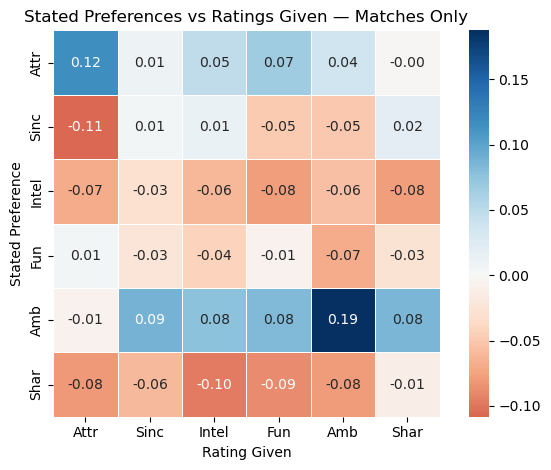

In [13]:

corr = df[matchs_yes][stated_preferences_t1 + scorecard[:6]].dropna().corr().loc[stated_preferences_t1, scorecard[:6]]
corr.index = corr.columns = ['Attr', 'Sinc', 'Intel', 'Fun', 'Amb', 'Shar']

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0, linewidths=0.5, linecolor='white', square=True)
plt.title("Stated Preferences vs Ratings Given — Matches Only")
plt.xlabel("Rating Given")
plt.ylabel("Stated Preference")
plt.tight_layout()
plt.show()

We observe scores that are all close to zero. This seems to indicate that preferences do not have any real impact on matches.

That said, we can still note a few interesting points:
People who value sincerity tend to place less importance on attractiveness when choosing a partner. Conversely, those who value attractiveness rate it very slightly higher in their matches.

In any case, all of these correlations are too weak to be truly significant.

Now let’s look at how they evolve over time:

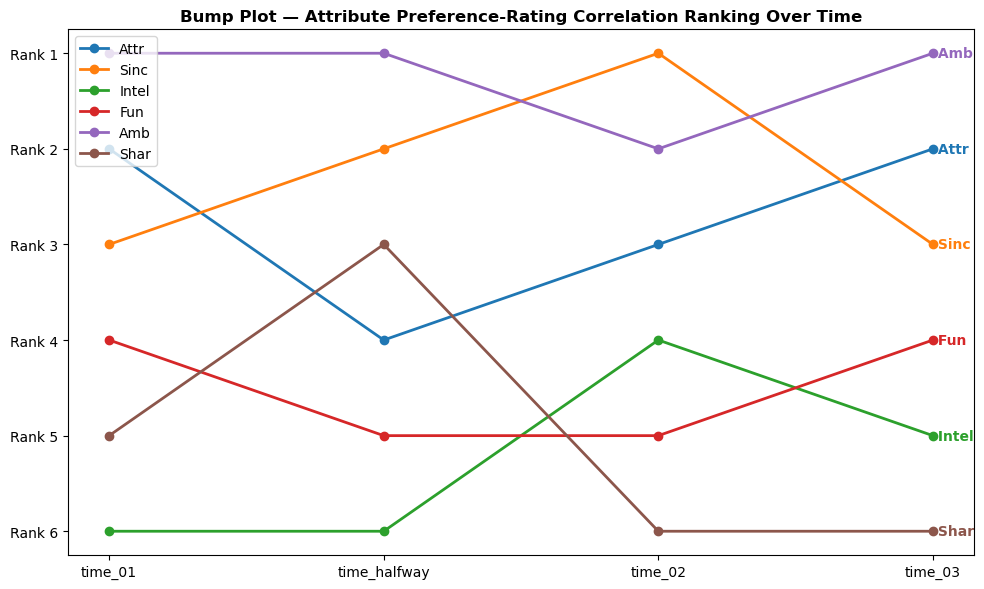

In [14]:
attrs = ['Attr', 'Sinc', 'Intel', 'Fun', 'Amb', 'Shar']
results = {}

for time_name, time_dict in ALL_RESPONSES.items():
    prefs = time_dict['q1']
    results[time_name] = [df[matchs_yes][p].corr(df[matchs_yes][r]) 
                          for p, r in zip(prefs, scorecard[:6])]

df_evolution = pd.DataFrame(results, index=attrs).T
df_ranks = df_evolution.rank(axis=1, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('tab10', len(attrs))

for j, attr in enumerate(attrs):
    ax.plot(df_ranks.index, df_ranks[attr], marker='o', label=attr, color=colors[j], linewidth=2)
    ax.text(df_ranks.index[-1], df_ranks[attr].iloc[-1], f' {attr}', 
            va='center', color=colors[j], fontweight='bold')

ax.set_yticks(range(1, len(attrs) + 1))
ax.set_yticklabels([f'Rank {i}' for i in range(1, len(attrs) + 1)])
ax.invert_yaxis()
ax.set_title("Bump Plot — Attribute Preference-Rating Correlation Ranking Over Time", fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


The variables begin and end in roughly the same positions. Only intelligence and shared interests switch places, but their initial scores are too low to indicate any meaningful impact.

We can therefore conclude that the explanation for matches does not lie in individuals’ stated preferences.

## 2.1.2. Ethnicity 

Now let’s examine whether there is a correlation between sharing the same ethnicity and matches.

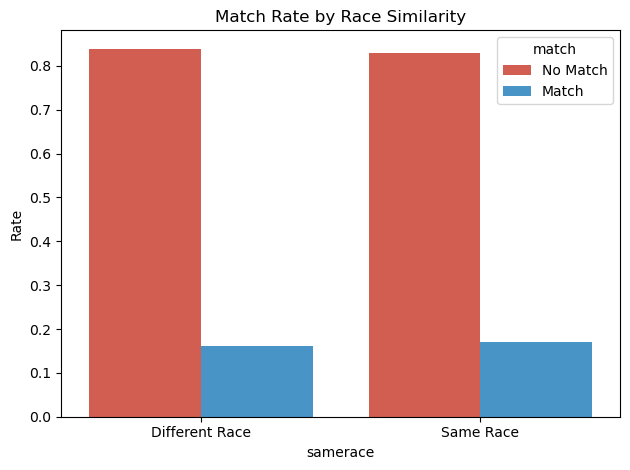

In [15]:
match_race = df.groupby(['samerace', 'match']).size().reset_index(name='count')
match_race['rate'] = match_race.groupby('samerace')['count'].transform(lambda x: x / x.sum())
match_race['match'] = match_race['match'].map({0: 'No Match', 1: 'Match'})

sns.barplot(data=match_race, x='samerace', y='rate', hue='match', 
            palette={'No Match': '#e74c3c', 'Match': '#3498db'})
plt.xticks([0, 1], ['Different Race', 'Same Race'])
plt.title("Match Rate by Race Similarity")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

The visual is very clear: ethnicity does not influence matches between individuals.

### 2.1.3. Occupations 

Now let’s look at whether people tend to match with others who work in the same professional field.

Before that, let’s merge the tables so we can access the partner’s field of study and social background.

In [16]:
df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin-1')

df['mn_sat'] = pd.to_numeric(df['mn_sat'], errors='coerce')

partner_cols = ['iid', 'field_cd', 'career_c', 'mn_sat']
df_partner = df[partner_cols].drop_duplicates(subset='iid').rename(columns={
    'iid': 'pid',
    'field_cd': 'field_cd_p',
    'career_c': 'career_c_p',
    'mn_sat': 'mn_sat_p'
})

df = df.merge(df_partner, on='pid', how='left')

df['same_field'] = (df['field_cd'] == df['field_cd_p']).astype(int)
df['same_career'] = (df['career_c'] == df['career_c_p']).astype(int)
df['sat_diff'] = (df['mn_sat'] - df['mn_sat_p']).abs()



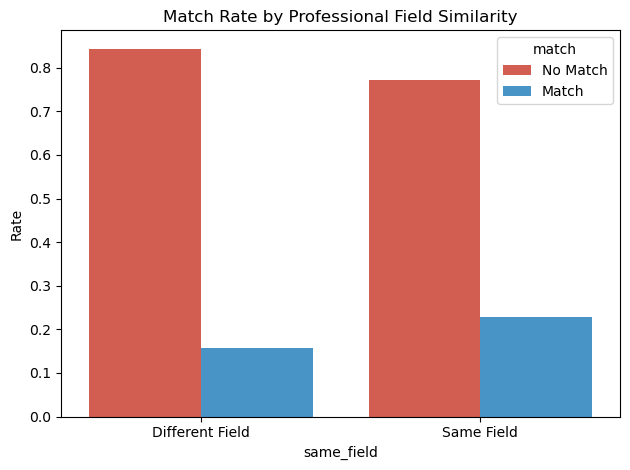

In [17]:
match_field = df.groupby(['same_field', 'match']).size().reset_index(name='count')
match_field['rate'] = match_field.groupby('same_field')['count'].transform(lambda x: x / x.sum())
match_field['match'] = match_field['match'].map({0: 'No Match', 1: 'Match'})

sns.barplot(data=match_field, x='same_field', y='rate', hue='match',
            palette={'No Match': '#e74c3c', 'Match': '#3498db'})
plt.xticks([0, 1], ['Different Field', 'Same Field'])
plt.title("Match Rate by Professional Field Similarity")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()


People in the same field tend to match slightly more often than others, but the difference remains too small to be truly significant.

Let’s take a closer, more detailed look.

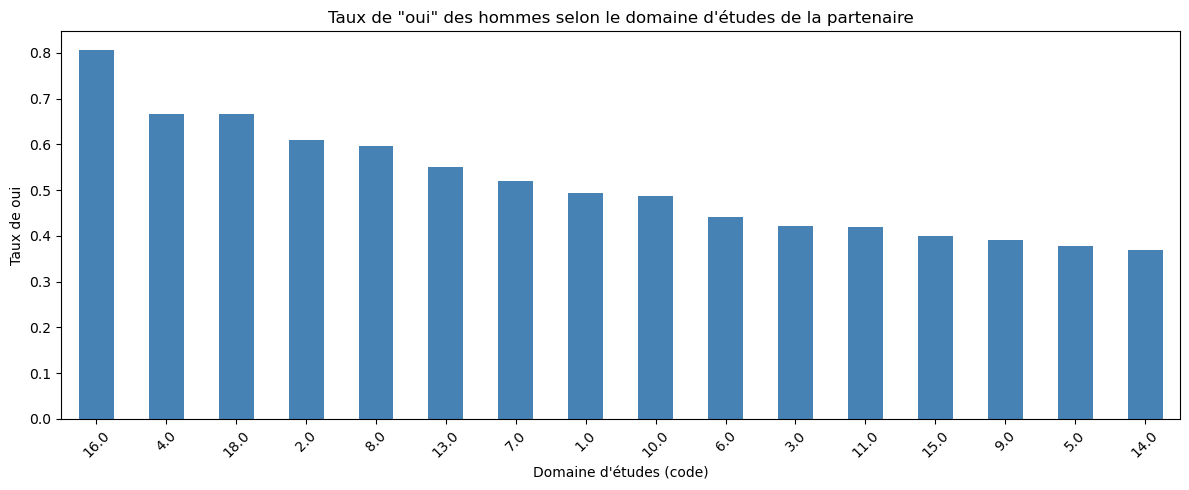

In [97]:
field_decisions = df[df['gender'] == 1][['dec', 'field_cd_p']].dropna()

match_rate = field_decisions.groupby('field_cd_p')['dec'].mean().sort_values(ascending=False)

match_rate.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title('Taux de "oui" des hommes selon le domaine d\'études de la partenaire')
plt.xlabel('Domaine d\'études (code)')
plt.ylabel('Taux de oui')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In conclusion, similarity does not appear to be the key to understanding why people match with each other. The correlations are too weak, and the difference between matches and non-matches is almost nonexistent.

In that case, let’s try to see whether certain combinations stand out from the rest.

## 3. Machine learning analysis

To identify these combinations, we will use machine learning.

We will try different models and then combine them into an ensemble.

### 3.1. Logistic Regression 

First, we’ll perform preprocessing so we can use the data with a model.     
This will also allow us to highlight the most important variables before considering combining them.    

### 3.1.1. Preprocessing 

First, let’s look at the percentage of missing values.

In [18]:
# We re-import the dataset after our initial analysis
df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin-1')

# isna() returns a boolean value, so the results are represented as 0 and 1
# That’s why we multiply them by 100 to express the proportion as a percentage.
missing = df.isna().mean() * 100

# First, let’s look at how many columns are affected.
display(len(missing[missing > 0]))


182

182 columns are affected. We will therefore isolate the ones that truly cannot be retained because they contain too many missing values.

In [19]:
display(len(missing[missing > 50]))

59

59 is a significant number. Let’s take a look at the affected columns to assess how useful they are.

In [20]:
display(missing[missing > 50])

mn_sat      62.604440
tuition     57.233230
expnum      78.515159
attr1_s     51.110050
sinc1_s     51.110050
intel1_s    51.110050
fun1_s      51.110050
amb1_s      51.110050
shar1_s     51.110050
attr3_s     52.255908
sinc3_s     52.255908
intel3_s    52.255908
fun3_s      52.255908
amb3_s      52.255908
attr7_2     76.318931
sinc7_2     76.665075
intel7_2    76.318931
fun7_2      76.318931
amb7_2      76.665075
shar7_2     76.438291
you_call    52.566245
them_cal    52.566245
date_3      52.566245
numdat_3    82.143710
num_in_3    92.026737
attr1_3     52.566245
sinc1_3     52.566245
intel1_3    52.566245
fun1_3      52.566245
amb1_3      52.566245
shar1_3     52.566245
attr7_3     75.936978
sinc7_3     75.936978
intel7_3    75.936978
fun7_3      75.936978
amb7_3      75.936978
shar7_3     75.936978
attr4_3     64.681308
sinc4_3     64.681308
intel4_3    64.681308
fun4_3      64.681308
amb4_3      64.681308
shar4_3     64.681308
attr2_3     64.681308
sinc2_3     64.681308
intel2_3  

These are the attributes concerned. They are fundamental to the experience, so we will need to use models that can handle NaN values without being affected.

For now, we are still working on the baseline. So, we will remove these columns for the linear regression model and bring them back later.

In [21]:
df_baseline = df.loc[:, missing <= 50 ]
print(f" Our dataset goes from {df.shape[1]} to {df_baseline.shape[1]} columns")

 Our dataset goes from 195 to 136 columns


#### 3.1.1.1. Define features and target

Now let’s separate the target from the explanatory variables. Otherwise, we might end up normalizing it along with the rest.

In [22]:
target = 'match'
y = df_baseline[target]
X = df_baseline.drop(columns=target)
display(y)

0       0
1       0
2       1
3       1
4       1
       ..
8373    0
8374    0
8375    0
8376    0
8377    0
Name: match, Length: 8378, dtype: int64

But be careful: this dataset contains several match-related columns. We’re going to remove them for the baseline.

In [23]:
target_leakage = match_during_event + match_follow_up 

We must respect the temporal order in our prediction. Therefore, we also need to remove everything that occurs after the event.

In [24]:
post_event = satisfaction_post_event

We must respect the temporal order in our prediction. Therefore, we also need to remove everything that occurs after the event. Fortunately, our group identifier also included everything related to event logistics, which would have introduced bias.

In [25]:
id_columns = identifiers 

In [26]:
X = df_baseline.drop(columns= target_leakage + post_event + id_columns, errors="ignore")
print(X.columns.tolist())

['int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'field_cd', 'undergra', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'income', 'goal', 'date', 'go_out', 'career', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'met', 'attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2', 'attr4_2', 'sinc4_2', 'in

Now we will separate the categorical and numerical columns so we can later standardize them.

In [27]:
numeric_features = X.select_dtypes("number").columns.tolist()
categorical_features = X.select_dtypes("object").columns.tolist()
print("Found numeric features", numeric_features)
print("Found categorical features", categorical_features)

Found numeric features ['int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field_cd', 'race', 'imprace', 'imprelig', 'goal', 'date', 'go_out', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'met', 'attr1_2', 'sinc1_2', 'intel1_2', 'fun1_2', 'amb1_2', 'shar1_2', 'attr4_2', 'sinc4_2', 'intel4_2', 'fun4_2', 'amb4_2', 'shar4_2

#### 3.1.1.2. Categorical feature processing

Wait, let’s take a closer look at our categorical features.

In [28]:
display(df_baseline[categorical_features].head(10))

,field,undergra,from,zipcode,income,career
0,Law,NaN,Chicago,"60,521","69,487.00",lawyer
1,Law,NaN,Chicago,"60,521","69,487.00",lawyer
2,Law,NaN,Chicago,"60,521","69,487.00",lawyer
3,Law,NaN,Chicago,"60,521","69,487.00",lawyer
4,Law,NaN,Chicago,"60,521","69,487.00",lawyer
5,Law,NaN,Chicago,"60,521","69,487.00",lawyer
6,Law,NaN,Chicago,"60,521","69,487.00",lawyer
7,Law,NaN,Chicago,"60,521","69,487.00",lawyer
8,Law,NaN,Chicago,"60,521","69,487.00",lawyer
9,Law,NaN,Chicago,"60,521","69,487.00",lawyer


We have several issues:         
we need to group zip codes based on the implicit wealth level they indicate so that they become usable. Also, this would introduce too many different categories during normalization. It’s better to drop this variable.   
“Undergrad” has the same issue: if we keep it, it would lead to too many distinct categories.                      

For the career and field variables, we already have the encoded versions, so we can remove the categorical versions.        

In [29]:
categoric_drop = ["field", "undergra" , "zipcode", "career"]

X = df_baseline.drop(columns=target_leakage + post_event + identifiers + categoric_drop, errors="ignore")
categorical_features = X.select_dtypes("object").columns.tolist()
display(df_baseline[categorical_features].head(10))

,from,income
0,Chicago,"69,487.00"
1,Chicago,"69,487.00"
2,Chicago,"69,487.00"
3,Chicago,"69,487.00"
4,Chicago,"69,487.00"
5,Chicago,"69,487.00"
6,Chicago,"69,487.00"
7,Chicago,"69,487.00"
8,Chicago,"69,487.00"
9,Chicago,"69,487.00"


All that’s left is to convert the “income” column to a float.       
It contains commas, so we’ll replace them with dots during the conversion.      

We will apply this transformation directly to the original dataset. That way, we won’t have to redo it every time.

In [30]:
df["income"] = df["income"].str.replace(",", "").astype(float)
df_baseline = df.loc[:, missing <= 50]
X = df_baseline.drop(columns=target_leakage + post_event + identifiers + categoric_drop, errors="ignore")

# Upload features
categorical_features = X.select_dtypes("object").columns.tolist()
numeric_features = X.select_dtypes("number").columns.tolist()
print("Ctegorical features", categorical_features)

Ctegorical features ['from']


Now let’s focus on these cities. Let’s check how many different values there are.

In [31]:
X["from"].nunique()

269

269 is far too many for a OneHotEncoder. Can we group them?

They could reflect a level of wealth, but that’s relative. Two people living in Chicago don’t necessarily pay the same depending on their location.

We could still simplify this with a binary split: rural vs urban. To do that, we’d need a tool that understands which places are countryside and which are cities, so we’d have to rely on a small LLM for that.

In [32]:
load_dotenv()
token = os.getenv("HF_TOKEN")


In [33]:
# We are using Ollama, which runs locally on our computer and is free. 
# You need to download it
# Prompt for the LLM: {Cities} will contain the list of different city names.
# We ask it to return a dictionary

# Create file if it doesn't already exist
os.makedirs('models', exist_ok=True)
path_cities = 'models/cities_type.json'

# Condition allows skipping training if it has already been done.
if not os.path.exists(path_cities):
    # We provide the list of city names
    cities = X["from"].dropna().unique().tolist()
    # We invoke ollama
    response = ollama.chat(
        model="llama3.2",
        # The prompt
        messages=[{"role": "user", "content": f"""Classify each location as 'urban' or 'rural'.
Return ONLY a valid JSON object, no comments, no extra text.
Example: {{"New York": "urban", "Iowa": "rural"}}
Locations: {cities}"""}],
        format="json"
    )
    # Creat file
    with open(path_cities, 'w') as f:
        f.write(response['message']['content'])
# Read file
with open(path_cities, 'r') as f:
    cities_type = f.read()

X["from_urban"] = X["from"].map(json.loads(cities_type))
X = X.drop(columns=["from"])
print(X["from_urban"].value_counts())


from_urban
urban    3288
rural     588
Name: count, dtype: int64


In [34]:
print(X["from_urban"].isna().mean() * 100)

53.73597517307233


For the baseline, we remove everything with more than 40% missing values. But what we’ve done here will still be useful for future models.

#### 3.1.1.3. Numeric feature processing

As a reminder, since this is a baseline, we are removing these attributes because they contained too many missing values to be used with linear regression.


In [35]:
missing = X[numeric_features].isna().mean() * 100
missing_to_drop = missing[missing > 40].index.tolist()
print(missing_to_drop)

['income', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'attr5_2', 'sinc5_2', 'intel5_2', 'fun5_2', 'amb5_2']


Interesting observation: when missing values exceed 40%, we only lose attributes related to the question **“And finally, how do you think others perceive you?”**.

It seems participants were often reluctant to answer this question. We will therefore remove these features from the dataset.

In [36]:
X = X.drop(columns=missing_to_drop)
# We recompute the lists after dropping the columns
numeric_features = X.select_dtypes("number").columns.tolist()
categorical_features = X.select_dtypes("object").columns.tolist()

Let’s look at the other columns with missing values. We will apply median imputation for float variables and mean imputation for integer variables.

In [37]:
int_columns = X[numeric_features].select_dtypes("int").columns.tolist()
float_columns = X[numeric_features].select_dtypes("float").columns.tolist()

In [38]:
display(missing[int_columns])
display(missing[float_columns])

samerace    0.0
dtype: float64

int_corr     1.885892
age_o        1.241346
race_o       0.871330
pf_o_att     1.062306
pf_o_sin     1.062306
              ...    
attr3_2     10.921461
sinc3_2     10.921461
intel3_2    10.921461
fun3_2      10.921461
amb3_2      10.921461
Length: 100, dtype: float64

We will also remove “like” and “prob”, as they would cause data leakage as well as all the feedback collected during the date because we want to predict whether two people will match before they meet.

In [39]:
during_event_leakage = [
    # Scores donnés pendant le date
    'like', 'like_o', 'prob', 'prob_o', 'met', 'met_o',
    # Scores du partenaire pendant le date
    'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o',
    # Scores que tu donnes au partenaire pendant le date
    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar',
    # Corrélation calculée après
    'int_corr',
    # Préférences du partenaire
    'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha'
]
# We clean the numerical features.
X = X.drop(columns=during_event_leakage, errors='ignore')
numeric_features = X.select_dtypes("number").columns.tolist()  # ← ligne 15
X = X[numeric_features]  

“Samemrace” is the only categorical variable stored as an integer, and it is a binary column. Everything else is a float, so we can use a median imputer for all of them.

Let’s move on to splitting the dataset.

Since we’re going to use several models and combine them, we introduce a validation set. It will allow us to properly compare model performance. If we relied only on the test set, our model selection would be biased.

### 3.1.2 Split 

In [40]:

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [41]:
print(f"X train shape: {X_train.shape} X test shape: {X_test.shape}")

X train shape: (6702, 76) X test shape: (1676, 76)



### 3.1.3 Pipeline of normalization

We will create a pipeline to normalize the data.

In [42]:
# Create a folder named models if it doesn’t already exist
# Allows skipping training if it has already been done.
os.makedirs('models', exist_ok=True)


# Numeric preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # For missing values
    ('scaler', StandardScaler()) # Logistic regression is sensitive to feature scales

])

# Applying the numerical pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
])

# Full ML pipeline to avoid data leakage and ensure reproducibility
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit and transform using cross-validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Cross validation and ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Allows skipping training if it has already been done.
path = 'models/logistic_regression.pkl'
if not os.path.exists(path):
    pipeline.fit(X_train, y_train)
    joblib.dump(pipeline, path)

pipeline = joblib.load(path)

Cross validation and ROC-AUC: 0.583 ± 0.024


Test ROC-AUC: 0.637
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1400
           1       0.00      0.00      0.00       276

    accuracy                           0.84      1676
   macro avg       0.42      0.50      0.46      1676
weighted avg       0.70      0.84      0.76      1676



c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

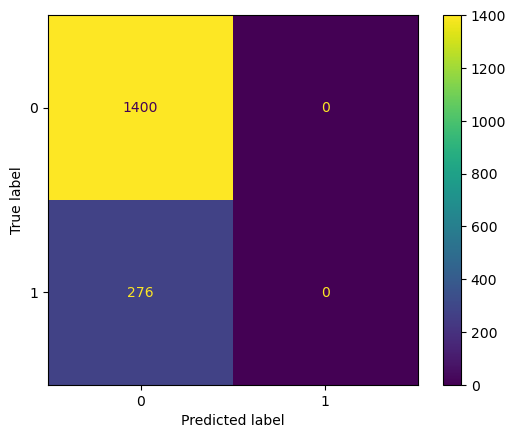

In [43]:
# Let’s look at the metrics.
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# ROC-AUC
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Precision, Recall, F1
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

### 3.1.4. Observations

Honestly, the only interpretation of these results is that predicting whether two people will match before they meet is extremely difficult. Our recall is simply 0.        
So there’s no point in looking at the most influential variables.       
        

But let’s move on to other types of models to see if they can find a starting point for a solution.

So we will now train several models and combine them using stacking.

Here is the plan for the upcoming models:

- Random Forest
-  XGBoost 
- Stacking 

Puis nous allons utiliser la réductioin de dimensions to better understand the relationships between important variables

## 3.2. Random Forest

Logistic regression allowed us to observe each variable independently. Random Forest, on the other hand, will now allow us to capture interactions between these variables.

In [44]:
# We will use Optuna to optimize hyperparameters.
# Definition of Optuna’s search space.
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    
    # Random Forest does not require StandardScaler.
    rf_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(**params, class_weight='balanced', random_state=42))
    ])
    
    # Evaluation using cross-validation.
    scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    return scores.mean()

path_study = 'models/rf_study.pkl'

# Skip if already done.
if not os.path.exists(path_study):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)
    joblib.dump(study, path_study)

# Running the Optuna optimization process.
study = joblib.load(path_study)

# Metrics
print(f"Best params: {study.best_params}")
print(f"Best CV ROC-AUC: {study.best_value:.3f}")

Best params: {'n_estimators': 315, 'max_depth': 11, 'min_samples_split': 14, 'max_features': 'sqrt'}
Best CV ROC-AUC: 0.637


              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1400
           1       0.29      0.51      0.37       276

    accuracy                           0.72      1676
   macro avg       0.59      0.64      0.60      1676
weighted avg       0.79      0.72      0.74      1676

ROC-AUC: 0.681


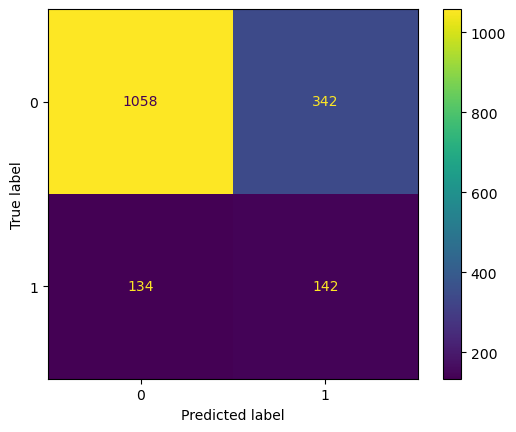

In [45]:
# File where the model is saved
path_rf = 'models/random_forest.pkl'

# Skip if already trained
if not os.path.exists(path_rf):
    # Model creation with the best hyperparameters
    best_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(**study.best_params, class_weight='balanced', random_state=42))
    ])
    # Training
    best_rf.fit(X_train, y_train)
    # Saving
    joblib.dump(best_rf, path_rf)

# Loading the model
best_rf = joblib.load(path_rf)
# Prediction
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

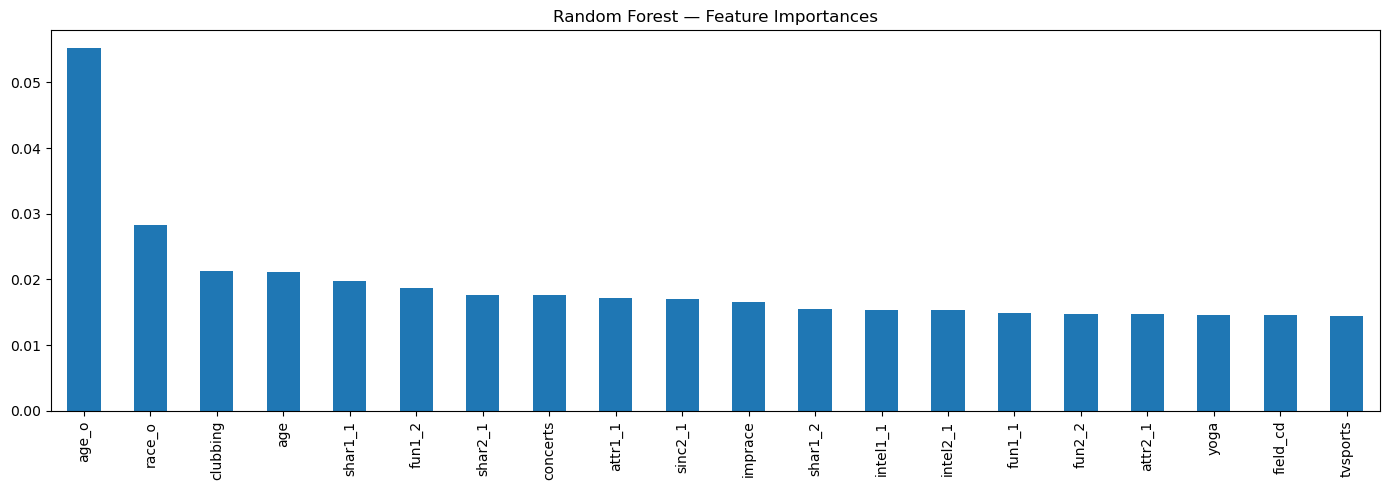

In [46]:
pd.Series(
    best_rf['classifier'].feature_importances_,
    index=numeric_features
).sort_values(ascending=False).head(20).plot(kind='bar', figsize=(14, 5))
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()


A glimmer of hope: the model achieved a 51% recall.

Age is by far the most important feature, followed by ethnic similarity. There is also interest in clubbing that stands out — perhaps these are people who are more used to matching with others during nights out, or who actively seek it more often.

Let’s look at the most influential combinations of variables.

In [47]:
from sklearn.tree import export_text
# Extraire un arbre representatif (le premier par exemple)
tree = best_rf['classifier'].estimators_[0]
rules = export_text(tree, feature_names=numeric_features, max_depth=4)
print(rules)

|--- sinc1_1 <= 14.62
|   |--- fun4_1 <= 6.00
|   |   |--- shopping <= 6.50
|   |   |   |--- reading <= 9.50
|   |   |   |   |--- attr4_2 <= 45.00
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- attr4_2 >  45.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- reading >  9.50
|   |   |   |   |--- class: 1.0
|   |   |--- shopping >  6.50
|   |   |   |--- shar2_2 <= 4.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- shar2_2 >  4.00
|   |   |   |   |--- attr2_2 <= 42.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- attr2_2 >  42.50
|   |   |   |   |   |--- class: 1.0
|   |--- fun4_1 >  6.00
|   |   |--- age <= 22.50
|   |   |   |--- intel1_1 <= 27.50
|   |   |   |   |--- career_c <= 3.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- career_c >  3.50
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- intel1_1 >  27.50
|   |   |   |   |--- intel4_1 <= 20.00
|   |   |   |   |   |--- truncated branch of

Sincerity is the clear winner. Those who consider it an important criterion start off on a strong foundation for matching. It then combines with fun and intelligence.       
What is interesting is that attractiveness comes at the end of the branch. It is therefore a confirming factor, but not one that initiates a match. Similarly, shared interests also appear at the end of the branch.       
Clubbing is more prominent, possibly because these are people who are more accustomed to being in a flirting or dating context.

## 3.3. XGBoost

We have a major issue with the imbalance between matches and non-matches. The Random Forest and Logistic Regression models simply tended to predict that there was no match.

XGBoost builds trees that correct the errors of previous ones. It will therefore naturally focus on the more difficult cases, here the matches.

In [48]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': 1400 / 276,
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', XGBClassifier(**params))])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc').mean()

if not os.path.exists('models/xgb_study.pkl'):
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=50)
    joblib.dump(study_xgb, 'models/xgb_study.pkl')
study_xgb = joblib.load('models/xgb_study.pkl')

if not os.path.exists('models/xgboost.pkl'):
    best_xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', XGBClassifier(
            **study_xgb.best_params,
            scale_pos_weight=1400 / 276,
            random_state=42,
            eval_metric='auc',
            verbosity=0
        ))
    ])
    best_xgb.fit(X_train, y_train)
    joblib.dump(best_xgb, 'models/xgboost.pkl')
best_xgb = joblib.load('models/xgboost.pkl')

print(classification_report(y_test, best_xgb.predict(X_test)))
print(f"ROC-AUC: {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]):.3f}")


              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1400
           1       0.28      0.57      0.37       276

    accuracy                           0.69      1676
   macro avg       0.59      0.64      0.58      1676
weighted avg       0.79      0.69      0.72      1676

ROC-AUC: 0.683


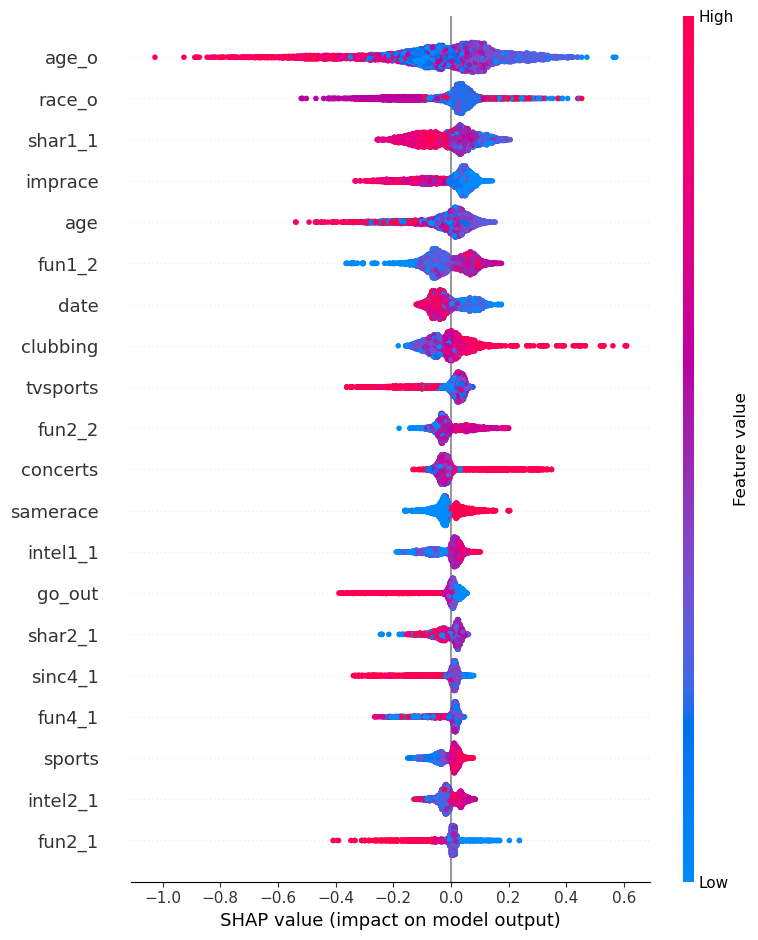

In [49]:

explainer = shap.TreeExplainer(best_xgb['classifier'])
X_train_imputed = best_xgb['imputer'].transform(X_train)
shap_values = explainer.shap_values(X_train_imputed)

# Vue globale : quelles variables poussent vers match ou non-match
shap.summary_plot(shap_values, X_train_imputed, feature_names=numeric_features)


We observe two highly discriminative variables: age and ethnicity, confirmed by the “imprace” variable, which represents how much importance a person places on ethnic similarity. Once again, we see that clubbing is associated with a higher likelihood of matching.

In [50]:
# Decision tree
booster = best_xgb['classifier'].get_booster()
booster.feature_names = numeric_features
print(booster.get_dump(with_stats=False)[0])

0:[shar1_1<13.6400003] yes=1,no=2,missing=2
	1:[sinc4_1<16] yes=3,no=4,missing=4
		3:[attr1_1<15.0900002] yes=7,no=8,missing=8
			7:[amb3_2<9] yes=15,no=16,missing=16
				15:[attr1_1<14.29] yes=31,no=32,missing=32
					31:[field_cd<12] yes=63,no=64,missing=64
						63:leaf=0.00277638203
						64:leaf=0.0165057331
					32:[concerts<8] yes=65,no=66,missing=66
						65:leaf=0.0142759448
						66:leaf=0.00798552763
				16:[concerts<7] yes=33,no=34,missing=34
					33:[samerace<1] yes=67,no=68,missing=68
						67:leaf=0.00927578285
						68:leaf=0.000102693222
					34:[field_cd<6] yes=69,no=70,missing=70
						69:leaf=-0.00690546958
						70:leaf=0.000383053033
			8:[sports<7] yes=17,no=18,missing=18
				17:[goal<4] yes=35,no=36,missing=36
					35:[art<9] yes=71,no=72,missing=72
						71:leaf=-0.0032044421
						72:leaf=0.00560739264
					36:[attr2_2<19.5100002] yes=73,no=74,missing=74
						73:leaf=0.00210454175
						74:leaf=-0.0151931718
				18:[shar1_1<8.32999992] yes=37,no=38,missing=38

The winning combinations are:

When there are few shared interests: low expectations regarding attractiveness, and a creative or literary academic background.
When there is shared ethnicity, no interest in sports, and low importance given to shared interests.

One non-matching combination clearly stands out:

believing that others value honesty, combined with a different ethnicity and being a fan of TV sports (which is too specific to allow a meaningful interpretation).

Thus:
Creative or literary profiles are more likely to match with each other. They also appear to be less sensitive to lifestyle similarities and physical attractiveness.

The other branches are not specific enough to allow for a truly meaningful interpretation.

## 4. Feature engineering of relationships between candidates

So far, we have tried to identify a typical profile. However, a match occurs between two people facing each other, and this interaction needs to be reflected in our data.

### 4.1 Merge with the partner’s profile

We start by merging the datasets to reconstruct each partner’s full profile.

In [51]:
# Selection partener's columns
cols_to_merge = activities + ['attr3_1','sinc3_1','fun3_1','intel3_1','amb3_1',
                               'attr1_1','sinc1_1','fun1_1','intel1_1','amb1_1']

# We keep only one row per participant.
partner_profile = df[['iid'] + cols_to_merge].drop_duplicates('iid')
# We rename all columns by adding the partner suffix.
partner_profile = partner_profile.rename(columns={c: c+'_o' for c in cols_to_merge})
# We rename iid to pid to enable the merge.
partner_profile = partner_profile.rename(columns={'iid': 'pid'})
# We attach the partner’s profile to each row.
df = df.merge(partner_profile, on='pid', how='left')

We will now group together similar fields of study.

In [ ]:
# A: for litterary filed
# B: for creative
# C: For science
# E: for others 

field_groups = {
    1: 'A',   # Droit
    2: 'C',   # Maths
    3: 'A',    # Sciences sociales / Psycho
    4: 'C',   # Médecine / Bio tech
    5: 'C',   # Ingénierie
    6: 'A',   # Lettres / Journalisme
    7: 'A',   # Histoire / Philo
    8: 'E',   # Business / Finance
    9: 'E',   # Education
    10: 'C',  # Sciences
    11: 'A',  # Travail social
    12: 'E',  # Indécis
    13: 'A',  # Sciences politiques
    14: 'B',  # Film
    15: 'B',  # Beaux-arts
    16: 'A',  # Langues
    17: 'B',  # Architecture
    18: 'E'   # Autre
}

df['field_group'] = df['field_cd'].map(field_groups)

# Recuperation partner's field_cd 
df_field = df[['iid', 'field_cd']].drop_duplicates('iid').rename(columns={
    'iid': 'pid',
    'field_cd': 'field_cd_p'
})
df = df.merge(df_field, on='pid', how='left')

df['field_group_o'] = df['field_cd_p'].map(field_groups)
df['same_field_group'] = (df['field_group'] == df['field_group_o']).astype(int)


Now we do the same with activities

In [57]:
# A for culture
# B for sport
# C for pleasure 

hobby_groups = {
    'sports':    'B',  
    'tvsports':  'B',   
    'exercise':  'B',
    'dining':    'C',   
    'museums':   'A',  
    'art':       'A',
    'hiking':    'B',
    'gaming':    'C',   
    'clubbing':  'B',
    'reading':   'A',
    'tv':        'C',
    'theater':   'A',
    'movies':    'A',
    'concerts':  'A',
    'music':     'A',
    'shopping':  'C',
    'yoga':      'B'
}

# Retrieve the activity columns
activity_scores = df[activities]
# For each person, find the column with the highest score and convert its name into a letter
df['main_hobby'] = activity_scores.idxmax(axis=1).map(hobby_groups)

# Do the same for the partner
activity_scores_o = df[[f'{a}_o' for a in activities]].copy()
activity_scores_o.columns = activities
df['main_hobby_o'] = activity_scores_o.idxmax(axis=1).map(hobby_groups)

# Then compare whether both individuals share the same dominant hobby.
df['same_hobby_group'] = (df['main_hobby'] == df['main_hobby_o']).astype(int)

C:\Users\axelv\AppData\Local\Temp\ipykernel_50324\914947884.py:28: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['main_hobby'] = activity_scores.idxmax(axis=1).map(hobby_groups)
C:\Users\axelv\AppData\Local\Temp\ipykernel_50324\914947884.py:33: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['main_hobby_o'] = activity_scores_o.idxmax(axis=1).map(hobby_groups)


In [56]:
# Difference in activities between the two individuals
for act in activities:
    df[f'{act}_diff'] = abs(df[act] - df[f'{act}_o'])

# Age gap
df['age_diff'] = abs(df['age'] - df['age_o'])

# Preference alignment: what A is looking for vs how B is ratedfor attr in ['attr','sinc','fun','intel','amb']:
for attr in ['attr', 'sinc', 'fun', 'intel', 'amb']:
    df[f'{attr}_alignment'] = abs(df[f'{attr}1_1'] - df[f'{attr}3_1_o'])


In [53]:
print(df.columns.tolist())


['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position', 'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'field_cd', 'undergra', 'mn_sat', 'tuition', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'income', 'goal', 'date', 'go_out', 'career', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'expnum', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'de

## 4.1. XGboost with the new features 

Now that we have these compatibility features, let’s build a new X using these features and retrain the XGBoost model. 

In [ ]:
# Individual profile test + compatibility features
compat_features = (
    [f'{act}_diff' for act in activities] +
    ['age_diff', 'same_field_group', 'same_hobby_group'] +
    [f'{attr}_alignment' for attr in ['attr', 'sinc', 'fun', 'intel', 'amb']]
)

# X enriched with both types of features
X_compat = df[numeric_features + compat_features].dropna(how='all')
y_compat = df.loc[X_compat.index, 'match']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_compat, y_compat, test_size=0.2, random_state=42, stratify=y_compat
)

print(f"X_compat shape: {X_compat.shape}")


X_compat shape: (8378, 101)


In [ ]:
# Optuna objective function 
def objective_xgb_compat(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': 1400 / 276,
        'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0
    }
    # Pipeline with XGBoost
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', XGBClassifier(**params))])
    return cross_val_score(pipe, X_train_c, y_train_c, cv=5, scoring='roc_auc').mean()

# Pass if it already exist
if not os.path.exists('models/xgb_compat_study.pkl'):
    # Optuna study
    study_xgb_compat = optuna.create_study(direction='maximize')
    study_xgb_compat.optimize(objective_xgb_compat, n_trials=50)
    joblib.dump(study_xgb_compat, 'models/xgb_compat_study.pkl')
study_xgb_compat = joblib.load('models/xgb_compat_study.pkl')

# training final model
if not os.path.exists('models/xgboost_compat.pkl'):
    xgb_compat = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', XGBClassifier(**study_xgb_compat.best_params, scale_pos_weight=1400/276, random_state=42, eval_metric='auc', verbosity=0))
    ])
    xgb_compat.fit(X_train_c, y_train_c)
    joblib.dump(xgb_compat, 'models/xgboost_compat.pkl')
xgb_compat = joblib.load('models/xgboost_compat.pkl')

# Threshold to 0.3 for a model more sensitive to positives
threshold = 0.3
y_proba_c = xgb_compat.predict_proba(X_test_c)[:, 1]
y_pred_thresh = (y_proba_c >= threshold).astype(int)

print(classification_report(y_test_c, y_pred_thresh))
print(f"ROC-AUC: {roc_auc_score(y_test_c, y_proba_c):.3f}")

[I 2026-04-15 20:54:40,401] A new study created in memory with name: no-name-f356d3ec-75ae-4db1-8287-0b0388f6bf4b
[I 2026-04-15 20:54:44,758] Trial 0 finished with value: 0.6941679814101158 and parameters: {'n_estimators': 404, 'max_depth': 8, 'learning_rate': 0.24261178302734362, 'subsample': 0.7817442990337176, 'colsample_bytree': 0.9426924719239349}. Best is trial 0 with value: 0.6941679814101158.
[I 2026-04-15 20:54:47,300] Trial 1 finished with value: 0.6670248515447912 and parameters: {'n_estimators': 382, 'max_depth': 5, 'learning_rate': 0.010447986612238582, 'subsample': 0.5477093390508809, 'colsample_bytree': 0.5697926501621327}. Best is trial 0 with value: 0.6941679814101158.
[I 2026-04-15 20:54:49,842] Trial 2 finished with value: 0.6709094959999785 and parameters: {'n_estimators': 208, 'max_depth': 8, 'learning_rate': 0.16883206553365668, 'subsample': 0.6230554093535985, 'colsample_bytree': 0.5889401813757773}. Best is trial 0 with value: 0.6941679814101158.
[I 2026-04-15 2

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1400
           1       0.54      0.36      0.43       276

    accuracy                           0.84      1676
   macro avg       0.71      0.65      0.67      1676
weighted avg       0.83      0.84      0.83      1676

ROC-AUC: 0.773


The ROC-AUC increased from 0.683 to 0.773, which is a significant improvement. The recall is still low, but let’s see what happens if we lower the decision threshold

Now we will test using only the comparison features we created.

In [ ]:
# # Define a reduced feature set focusing only on compatibility signals between individuals
compat_only_features = (
    [f'{act}_diff' for act in activities] +
    ['age_diff', 'same_field_group', 'same_hobby_group'] +
    [f'{attr}_alignment' for attr in ['attr', 'sinc', 'fun', 'intel', 'amb']]
)

# Select only compatibility-based features from the dataset
X_compat_only = df[compat_only_features].dropna(how='all')
y_compat_only = df.loc[X_compat_only.index, 'match']

# Split dataset 
X_train_co, X_test_co, y_train_co, y_test_co = train_test_split(
    X_compat_only, y_compat_only, test_size=0.2, random_state=42, stratify=y_compat_only
)

print(f"Shape: {X_compat_only.shape}")


Shape: (8378, 25)


In [ ]:
from sklearn.metrics import make_scorer, f1_score

# Define F1-score as the evaluation metric, focusing on the positive class
scorer = make_scorer(f1_score, pos_label=1)

def objective_xgb_co(trial):
    # Define the hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': 1400 / 276,
        'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0
    }
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', XGBClassifier(**params))])
    # Evaluate model using 5-fold cross-validation with F1-score
    return cross_val_score(pipe, X_train_co, y_train_co, cv=5, scoring=scorer).mean()

# Pass if it aleardy exist
if not os.path.exists('models/xgb_co_study.pkl'):
    study_xgb_co = optuna.create_study(direction='maximize')
    study_xgb_co.optimize(objective_xgb_co, n_trials=50)
    joblib.dump(study_xgb_co, 'models/xgb_co_study.pkl')
# Load optimized study
study_xgb_co = joblib.load('models/xgb_co_study.pkl')

# Train final model if not already saved
if not os.path.exists('models/xgboost_co.pkl'):
    xgb_co = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', XGBClassifier(**study_xgb_co.best_params, scale_pos_weight=1400/276, random_state=42, eval_metric='auc', verbosity=0))
    ])
    xgb_co.fit(X_train_co, y_train_co)
    joblib.dump(xgb_co, 'models/xgboost_co.pkl')
xgb_co = joblib.load('models/xgboost_co.pkl')

print(classification_report(y_test_co, xgb_co.predict(X_test_co)))
print(f"ROC-AUC: {roc_auc_score(y_test_co, xgb_co.predict_proba(X_test_co)[:, 1]):.3f}")


[I 2026-04-15 20:59:39,871] A new study created in memory with name: no-name-645b11e9-f122-47f3-b13e-e8851fc2c3b7
[I 2026-04-15 20:59:41,156] Trial 0 finished with value: 0.42895626812808507 and parameters: {'n_estimators': 211, 'max_depth': 6, 'learning_rate': 0.044185374108498786, 'subsample': 0.7783717288998937, 'colsample_bytree': 0.8655885321903778}. Best is trial 0 with value: 0.42895626812808507.
[I 2026-04-15 20:59:42,462] Trial 1 finished with value: 0.38619717643107404 and parameters: {'n_estimators': 337, 'max_depth': 5, 'learning_rate': 0.2230445601113528, 'subsample': 0.5659089037132791, 'colsample_bytree': 0.639905010517757}. Best is trial 0 with value: 0.42895626812808507.
[I 2026-04-15 20:59:43,299] Trial 2 finished with value: 0.40773825809433417 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.13988290600958725, 'subsample': 0.9522000211368961, 'colsample_bytree': 0.8707333701953514}. Best is trial 0 with value: 0.42895626812808507.
[I 2026-04-

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1400
           1       0.75      0.61      0.67       276

    accuracy                           0.90      1676
   macro avg       0.84      0.78      0.81      1676
weighted avg       0.90      0.90      0.90      1676

ROC-AUC: 0.904


We now obtain a ROC-AUC of 0.904 and a recall of 0.61 on matches — we are finally getting closer to something meaningful. This suggests that individual features were adding noise. What predicts a match is therefore not a typical individual profile, but rather the interaction dynamics between two people.

In [ ]:
# Let’s look at the decision tree
booster_co = xgb_co['classifier'].get_booster()
booster_co.feature_names = compat_only_features
print(booster_co.get_dump(with_stats=False)[0])


0:[reading_diff<5] yes=1,no=2,missing=2
	1:[age_diff<6] yes=3,no=4,missing=4
		3:[same_field_group<1] yes=7,no=8,missing=8
			7:[yoga_diff<6] yes=15,no=16,missing=16
				15:[reading_diff<3] yes=31,no=32,missing=32
					31:[exercise_diff<2] yes=59,no=60,missing=60
						59:[gaming_diff<6] yes=101,no=102,missing=102
							101:[clubbing_diff<3] yes=157,no=158,missing=158
								157:[hiking_diff<4] yes=229,no=230,missing=230
									229:[tvsports_diff<1] yes=315,no=316,missing=316
										315:leaf=-0.01211718
										316:leaf=0.0191144682
									230:[yoga_diff<3] yes=317,no=318,missing=318
										317:leaf=0.0152159547
										318:leaf=-0.0274348632
								158:[art_diff<6] yes=231,no=232,missing=232
									231:[theater_diff<2] yes=319,no=320,missing=320
										319:leaf=0.00183253072
										320:leaf=-0.0275997594
									232:[sports_diff<6] yes=321,no=322,missing=322
										321:leaf=0.0234286748
										322:leaf=-0.0217878334
							102:[tv_diff<5] yes=159,no=160

What is interesting is that the first split changes completely, particularly regarding the difference in interest in reading. People who read and those who do not seem to represent two distinct profiles that struggle to match with each other.

For those with a small difference in reading interest:
- They tend to prefer partners of a similar age.
- They can match regardless of their field of study if they share similar activities, such as yoga or creative pursuits.

For individuals with a large difference in reading interest: 
- if they also differ in movie preferences, it results in a non-match

Reading and movies suggest that people match if they enjoy fictional content. 

## 4.2 SVM with the new features

We are looking for the boundary that separates matches from non-matches. This is a perfect task for a Support Vector Machine. Since the new features are differences, they form a space where compatible pairs are potentially clustered together

In [ ]:
def objective_svm(trial):
    # Hyperparameter search space
    params = {
        'C': trial.suggest_float('C', 0.01, 100, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly']),
        'class_weight': 'balanced'
    }
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', SVC(**params, probability=True, random_state=42))
    ])
    scorer = make_scorer(f1_score, pos_label=1)
    return cross_val_score(pipe, X_train_co, y_train_co, cv=5, scoring=scorer).mean()

# Pass if it already exist
if not os.path.exists('models/svm_study.pkl'):
    study_svm = optuna.create_study(direction='maximize')
    study_svm.optimize(objective_svm, n_trials=30)
    joblib.dump(study_svm, 'models/svm_study.pkl')
study_svm = joblib.load('models/svm_study.pkl')

if not os.path.exists('models/svm.pkl'):
    svm = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', SVC(**study_svm.best_params, probability=True, random_state=42))
    ])
    svm.fit(X_train_co, y_train_co)
    joblib.dump(svm, 'models/svm.pkl')
svm = joblib.load('models/svm.pkl')

print(classification_report(y_test_co, svm.predict(X_test_co)))
print(f"ROC-AUC: {roc_auc_score(y_test_co, svm.predict_proba(X_test_co)[:, 1]):.3f}")


[I 2026-04-15 21:16:58,824] A new study created in memory with name: no-name-a72e584a-6fd4-41e5-bdd0-11d70a51566f
[I 2026-04-15 21:17:17,722] Trial 0 finished with value: 0.28535055078924043 and parameters: {'C': 0.038864679699339835, 'kernel': 'linear'}. Best is trial 0 with value: 0.28535055078924043.
[I 2026-04-15 21:17:49,804] Trial 1 finished with value: 0.22686917545103374 and parameters: {'C': 0.017542704116594816, 'kernel': 'rbf'}. Best is trial 0 with value: 0.28535055078924043.
[I 2026-04-15 21:26:46,884] Trial 2 finished with value: 0.285236341910285 and parameters: {'C': 48.16516734201233, 'kernel': 'linear'}. Best is trial 0 with value: 0.28535055078924043.
[I 2026-04-15 21:27:14,828] Trial 3 finished with value: 0.4430390390661305 and parameters: {'C': 11.944300119218022, 'kernel': 'rbf'}. Best is trial 3 with value: 0.4430390390661305.
[I 2026-04-15 21:27:42,391] Trial 4 finished with value: 0.4408583951525415 and parameters: {'C': 11.371623189681756, 'kernel': 'rbf'}. B

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1400
           1       0.68      0.34      0.45       276

    accuracy                           0.87      1676
   macro avg       0.78      0.65      0.69      1676
weighted avg       0.85      0.87      0.85      1676

ROC-AUC: 0.778


The metrics, with a ROC-AUC of 0.778 and a recall of 0.34 on matches, are significantly worse than the latest XGBoost model. We will therefore discard this model.

## 4.3 LightGBM with the new features

This model is often better than XGBoost on imbalanced datasets, so let’s test it

In [ ]:
# Hyperparameters search space
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1
    }
    
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('classifier', LGBMClassifier(**params))])
    # F1 score focused on positive class
    scorer = make_scorer(f1_score, pos_label=1)
    return cross_val_score(pipe, X_train_co, y_train_co, cv=5, scoring=scorer).mean()

# Run Optuna if not already saved
if not os.path.exists('models/lgbm_study.pkl'):
    study_lgbm = optuna.create_study(direction='maximize')
    study_lgbm.optimize(objective_lgbm, n_trials=50)
    joblib.dump(study_lgbm, 'models/lgbm_study.pkl')
study_lgbm = joblib.load('models/lgbm_study.pkl')

# train LightGBM
if not os.path.exists('models/lgbm.pkl'):
    lgbm = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', LGBMClassifier(**study_lgbm.best_params, class_weight='balanced', random_state=42, verbose=-1))
    ])
    lgbm.fit(X_train_co, y_train_co)
    joblib.dump(lgbm, 'models/lgbm.pkl')
lgbm = joblib.load('models/lgbm.pkl')

print(classification_report(y_test_co, lgbm.predict(X_test_co)))
print(f"ROC-AUC: {roc_auc_score(y_test_co, lgbm.predict_proba(X_test_co)[:, 1]):.3f}")


[I 2026-04-15 21:52:04,382] A new study created in memory with name: no-name-ec913588-d3c7-4731-b3e8-f1db90443bda
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1400
           1       0.83      0.58      0.69       276

    accuracy                           0.91      1676
   macro avg       0.88      0.78      0.82      1676
weighted avg       0.91      0.91      0.91      1676

ROC-AUC: 0.918


c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM indeed outperforms XGBoost, with a ROC-AUC of 0.918 and a recall of 0.58 on matches.

Let’s now look at what features it used to achieve these results

c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


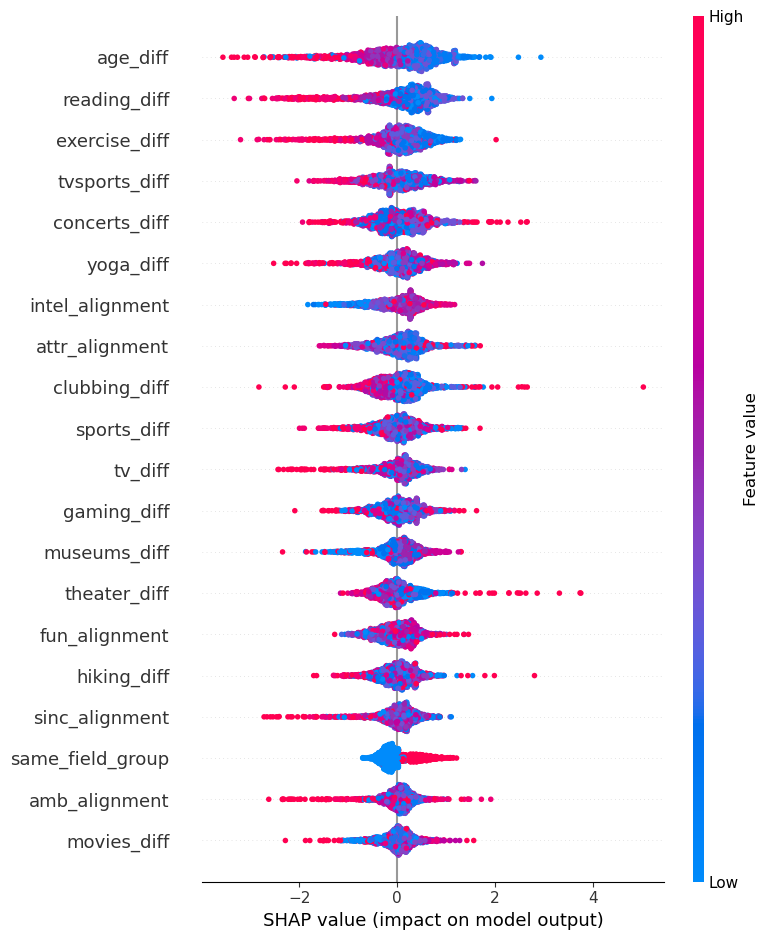

In [ ]:
# Extract the internal LightGBM model from the pipeline
explainer = shap.TreeExplainer(lgbm['classifier'])
# Apply exactly the same preprocessing transformations used during training
X_test_imputed = lgbm['imputer'].transform(X_test_co)
# Compute feature contributions using SHAP values
shap_values = explainer.shap_values(X_test_imputed)

shap.summary_plot(shap_values, X_test_imputed, feature_names=compat_only_features)


As for matches:  

- The plot clearly highlights the importance of age, reading and sports activities. People who match tend to be similar in age, reading habits, and sports interests.
- People who enjoy going to concerts and clubs also have a higher chance of matching. 

As for non-matches: 

- As for sincerity and ambition, if someone values these traits but their partner rates themselves poorly on them, it is more likely to result in a non-match.
- Finally, people who do not practice yoga are less likely to match with those who do.

In [78]:
# Let's see decision tree
from sklearn.tree import DecisionTreeClassifier, export_text

X_train_imp = lgbm['imputer'].transform(X_train_co)

dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt.fit(X_train_imp, y_train_co)

print(export_text(dt, feature_names=compat_only_features))


|--- reading_diff <= 4.50
|   |--- age_diff <= 3.50
|   |   |--- same_field_group <= 0.50
|   |   |   |--- yoga_diff <= 5.50
|   |   |   |   |--- class: 1
|   |   |   |--- yoga_diff >  5.50
|   |   |   |   |--- class: 0
|   |   |--- same_field_group >  0.50
|   |   |   |--- same_hobby_group <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- same_hobby_group >  0.50
|   |   |   |   |--- class: 1
|   |--- age_diff >  3.50
|   |   |--- concerts_diff <= 6.50
|   |   |   |--- concerts_diff <= 5.50
|   |   |   |   |--- class: 0
|   |   |   |--- concerts_diff >  5.50
|   |   |   |   |--- class: 0
|   |   |--- concerts_diff >  6.50
|   |   |   |--- gaming_diff <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- gaming_diff >  3.50
|   |   |   |   |--- class: 0
|--- reading_diff >  4.50
|   |--- movies_diff <= 2.50
|   |   |--- museums_diff <= 3.50
|   |   |   |--- dining_diff <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- dining_diff >  2.50
|   |   |   |   |--- class: 1
|   |  

We find the same patterns as before regarding the importance of reading, followed by similarity in fields of study. Yoga appears later in the tree but seems to play a highly discriminative role: after these variables, if both individuals practice yoga, a match is more likely, whereas if one of them does not, it tends to result in a non-match. But this may simply be due to noise in the dataset.

 
For those who do not share a similar relationship with reading, similarity in movie preferences once again appears to increase the likelihood of a match.

One surprising finding emerges from these models: there is very little room for individual attributes. Let’s see whether models with a different approach reach the same conclusion.

## 4.4. KNN 

XGBoost and LightGBM achieve better results, but they rely on similar methods. We will now use a radically different approach with KNN. This model is well suited for finding compatibility, as it focuses on similarity between observations

In [ ]:
# Search space
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan'])
    }
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(**params))
    ])
    scorer = make_scorer(f1_score, pos_label=1)
    return cross_val_score(pipe, X_train_co, y_train_co, cv=5, scoring=scorer).mean()

# Pass if already exist
if not os.path.exists('models/knn_study.pkl'):
    # Optuna
    study_knn = optuna.create_study(direction='maximize')
    study_knn.optimize(objective_knn, n_trials=50)
    joblib.dump(study_knn, 'models/knn_study.pkl')
study_knn = joblib.load('models/knn_study.pkl')

# Pass if already exist
if not os.path.exists('models/knn.pkl'):
    knn = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(**study_knn.best_params))
    ])
    knn.fit(X_train_co, y_train_co)
    joblib.dump(knn, 'models/knn.pkl')
knn = joblib.load('models/knn.pkl')

print(classification_report(y_test_co, knn.predict(X_test_co)))
print(f"ROC-AUC: {roc_auc_score(y_test_co, knn.predict_proba(X_test_co)[:, 1]):.3f}")


              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1400
           1       0.85      0.65      0.74       276

    accuracy                           0.92      1676
   macro avg       0.89      0.82      0.85      1676
weighted avg       0.92      0.92      0.92      1676

ROC-AUC: 0.893


KNN currently achieves the best recall for matches at 0.65, the highest precision at 0.85, and a strong ROC-AUC of 0.89.

Let’s now look at what it found.

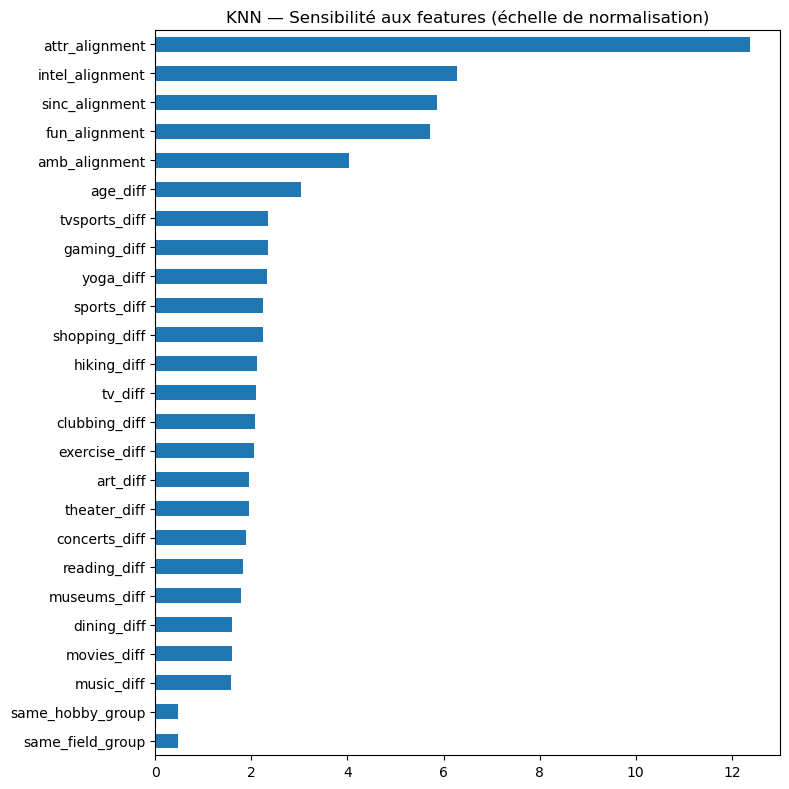

In [ ]:
# this is not true feature importance, but indicates how much each feature is rescaled
# this answer at "How importante each feature is for prediction"
importances = pd.Series(
    knn['scaler'].scale_, 
    index=compat_only_features
).sort_values()

importances.plot(kind='barh', figsize=(8, 8))
plt.title('KNN — Sensibilité aux features (échelle de normalisation)')
plt.tight_layout()
plt.show()


“Interestingly, it offers a completely different perspective from the other models. According to KNN, what predicts a match is the alignment of expectations. If the gap between what a person is looking for and how their partner rates themselves is small, a match becomes more likely.

This is especially true for attractiveness, which stands out by far as the most important factor, followed by intelligence, sincerity, and fun, which appear at a similar level.

One particularly interesting finding stands out: people who share the same hobbies do not necessarily match with each other. Let's take a closer look at this:


## 4.5. Stacking 

Now that we have models based on different approaches, let’s try stacking

In [ ]:
# Define base models for stacking ensemble
estimators = [
    ('lgbm', lgbm),
    ('xgb', xgb_co),
    ('knn', knn)
]
# Create stacking ensemble model
stacking_co = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    passthrough=False
)
# Path to saved stacking model
path_stack_co = 'models/stacking_co.pkl'

# Train and save model if it doesn't already exist
if not os.path.exists(path_stack_co):
    stacking_co.fit(X_train_co, y_train_co)
    joblib.dump(stacking_co, path_stack_co)
stacking_co = joblib.load(path_stack_co)

print(classification_report(y_test_co, stacking_co.predict(X_test_co)))
print(f"ROC-AUC: {roc_auc_score(y_test_co, stacking_co.predict_proba(X_test_co)[:, 1]):.3f}")


              precision    recall  f1-score   support

           0       0.96      0.91      0.94      1400
           1       0.65      0.83      0.73       276

    accuracy                           0.90      1676
   macro avg       0.81      0.87      0.83      1676
weighted avg       0.91      0.90      0.90      1676

ROC-AUC: 0.924


c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\axelv\anaconda3\envs\Python_3_13_5\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


The metrics are finally compelling! We achieve a ROC-AUC of 0.91 and a recall of 0.83 for matches.

Stacking gives us limited visibility into individual features, but it does provide important information: the weights assigned to each model. Let’s look at them.

In [ ]:
# Extract the final meta-model
meta = stacking_co.final_estimator_
# Retrieve learned coefficients of the meta-model
coefs = pd.Series(meta.coef_[0], index=['lgbm', 'xgb', 'knn'])
# Display model weights
print(coefs)


lgbm    2.122236
xgb     2.886410
knn     3.353948
dtype: float64


The stacking model assigns more importance to KNN. This suggests that the most important factor is the proximity between what a person is looking for and how individuals rate themselves on those attributes. This primarily concerns attractiveness, followed by intelligence, sincerity, and fun.

Let’s dig into this and look at how they evolve over time:

### 4.3.1 Going further into the analysis of attributes.
#### 4.3.1.1. Differences between genders.

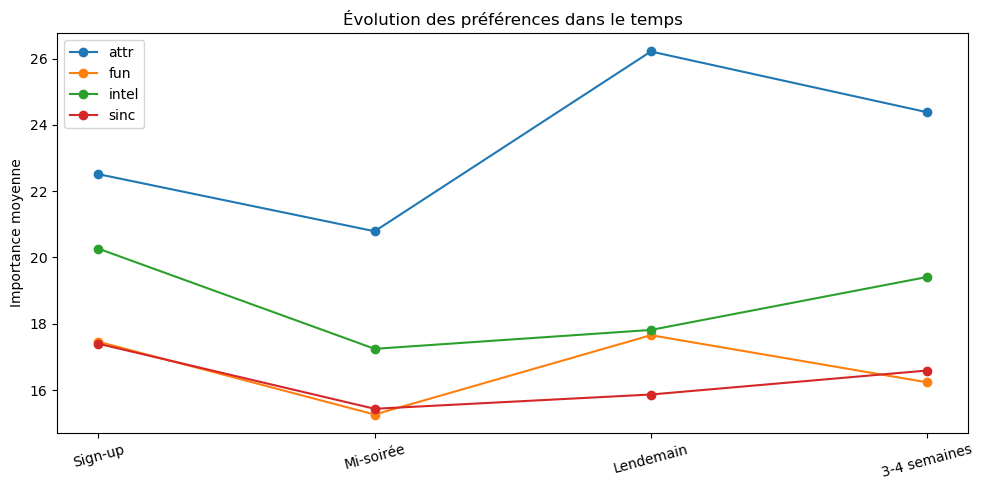

In [ ]:
# Define key attributes
attrs = ['attr', 'fun', 'intel', 'sinc']
# Map each time step to its corresponding feature
times = {
    'Sign-up': [f'{a}1_1' for a in attrs],
    'Mi-soirée': [f'{a}1_s' for a in attrs],
    'Lendemain': [f'{a}1_2' for a in attrs],
    '3-4 semaines': [f'{a}1_3' for a in attrs]
}

# Compute average values of each attribute at each time step
results = {}
for time_name, cols in times.items():
    results[time_name] = df[cols].mean().values
# Build a dataframe where rows = attributes and columns = time
df_evolution = pd.DataFrame(results, index=attrs).T

# Create line plot
plt.figure(figsize=(10, 5))
for attr in attrs:
    plt.plot(df_evolution.index, df_evolution[attr], marker='o', label=attr)

plt.title('Évolution des préférences dans le temps')
plt.ylabel('Importance moyenne')
plt.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


The pattern is clear: attractiveness dominates, and it even becomes more important over time. Let's see whether the same holds true across genders.


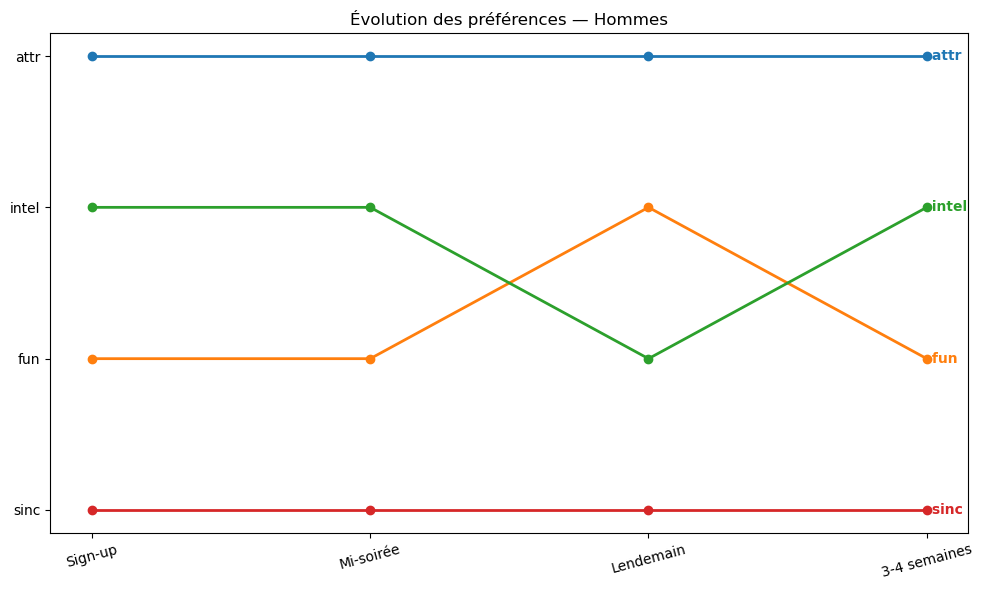

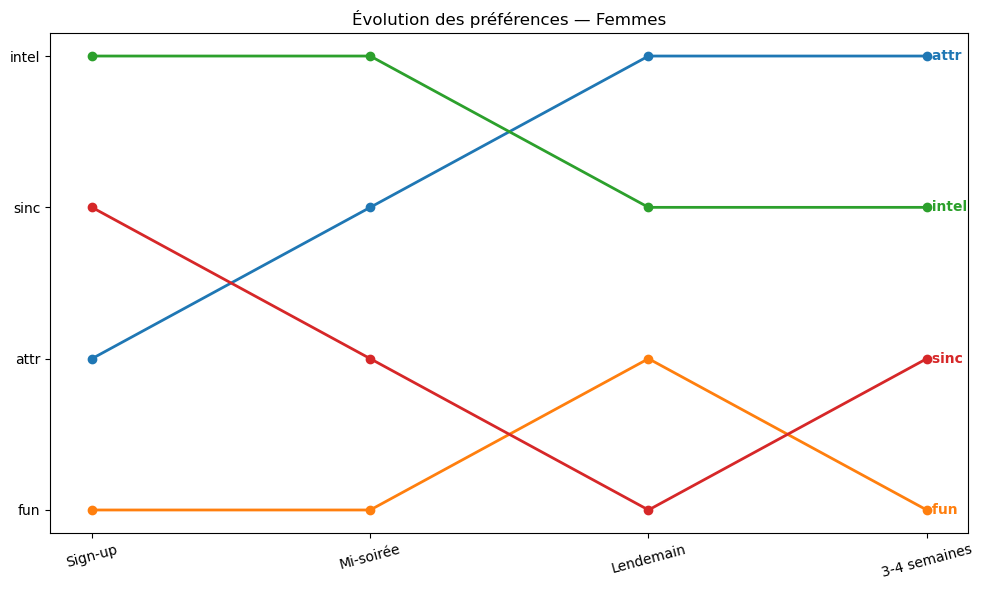

In [ ]:
# Loop over gender groups
for gender, title in [(1, 'Hommes'), (0, 'Femmes')]:
    # Store mean attribute values at each time
    results = {}
    for time_name, cols in times.items():
        results[time_name] = df[df['gender'] == gender][cols].mean().values
    # Build a dataframe: rows = attributes, columns = time steps
    df_evo = pd.DataFrame(results, index=attrs).T
    # Convert absolute values into rankings within each time step
    df_ranks = df_evo.rank(axis=1, ascending=False)
    
    # Extract attribute ordering at initial time step
    order_at_t1 = df_ranks.iloc[0].sort_values().index.tolist()
    
    colors = sns.color_palette('tab10', len(attrs))
    plt.figure(figsize=(10, 6))
    for i, attr in enumerate(attrs):
        plt.plot(df_ranks.index, df_ranks[attr], marker='o', label=attr, color=colors[i], linewidth=2)
        plt.text(df_ranks.index[-1], df_ranks[attr].iloc[-1], f' {attr}', 
                va='center', color=colors[i], fontweight='bold')
    
    plt.yticks(range(1, len(attrs) + 1), order_at_t1)
    plt.gca().invert_yaxis()
    plt.title(f'Évolution des préférences — {title}')
    plt.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()


In both cases, **attractiveness ranks first and intelligence comes second**.        
The **difference lies in how these preferences evolve**.    

For men, attractiveness consistently stays in the same position. Overall, we observe very little change among men: there is no difference between their preferences at the beginning and at the end of the experiment.      
For women, it starts in third place—behind intelligence and sincerity—before rising to first place the day after the date.

#### 4.3.1.2. Differences across fields of study.

Let’s see whether there are differences across fields of study.

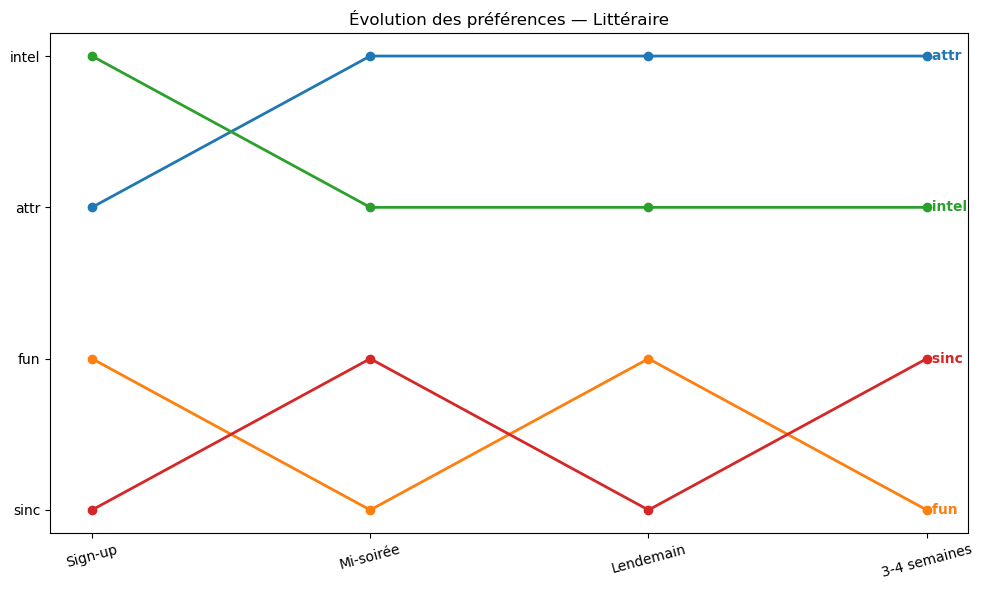

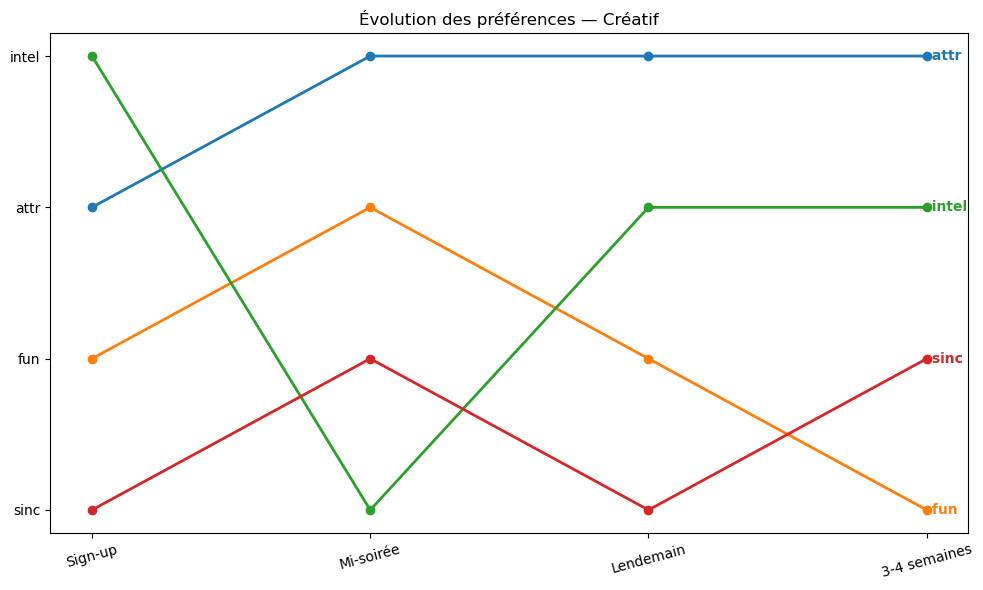

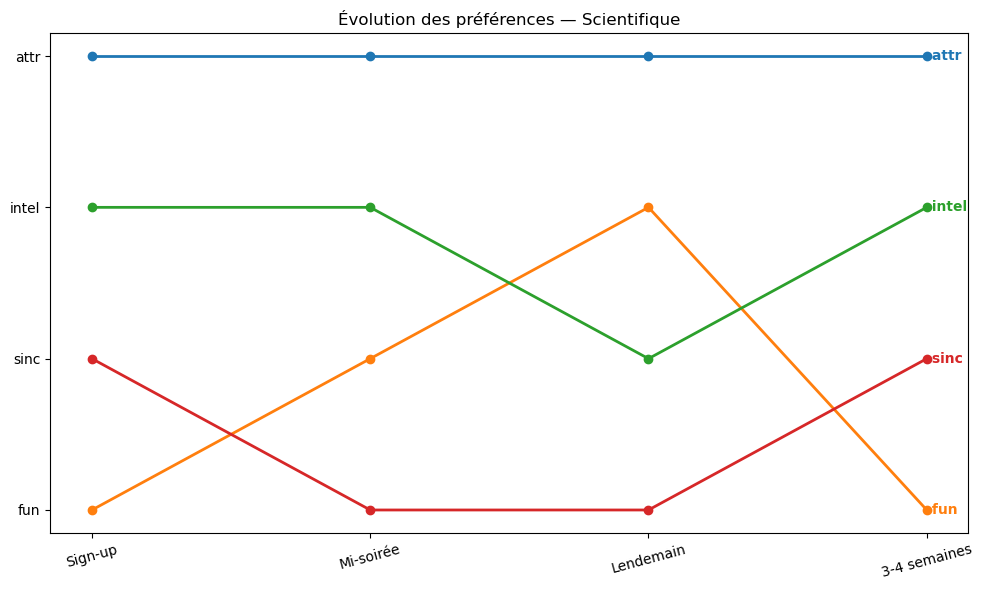

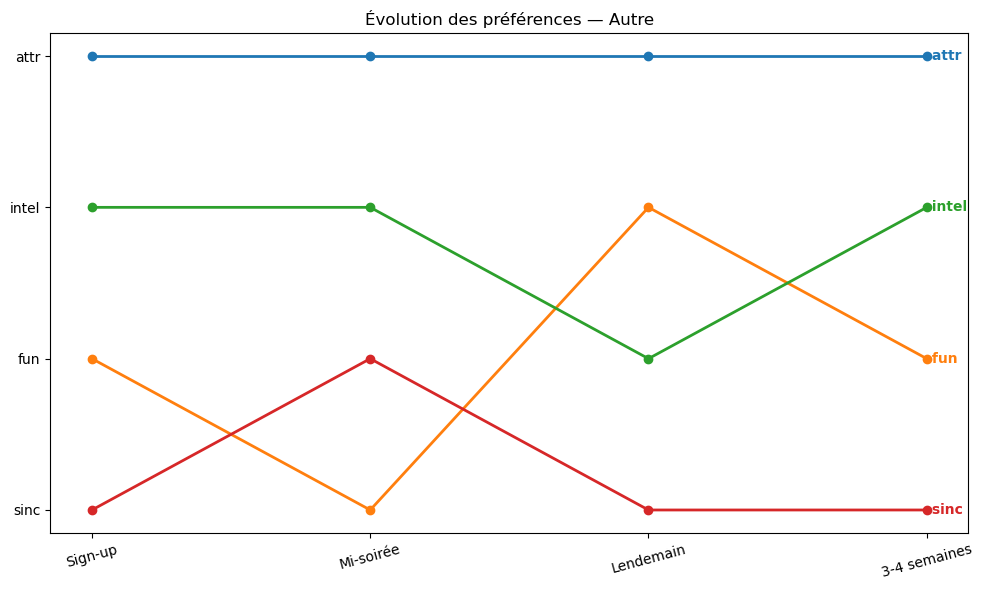

In [ ]:
group_names = {'A': 'Littéraire', 'B': 'Créatif', 'C': 'Scientifique', 'E': 'Autre'}

for group, group_label in group_names.items():
    mask = df['field_group'] == group
    results = {}
    for time_name, cols in times.items():
        results[time_name] = df[mask][cols].mean().values

    # Build dataframe: rows = attributes, columns = time steps
    df_evo = pd.DataFrame(results, index=attrs).T
    df_ranks = df_evo.rank(axis=1, ascending=False)
    order_at_t1 = df_ranks.iloc[0].sort_values().index.tolist()
    
    colors = sns.color_palette('tab10', len(attrs))
    plt.figure(figsize=(10, 6))
    # Plot ranking evolution for each attribute
    for i, attr in enumerate(attrs):
        plt.plot(df_ranks.index, df_ranks[attr], marker='o', label=attr, color=colors[i], linewidth=2)
        plt.text(df_ranks.index[-1], df_ranks[attr].iloc[-1], f' {attr}',
                va='center', color=colors[i], fontweight='bold')
    
    plt.yticks(range(1, len(attrs) + 1), order_at_t1)
    plt.gca().invert_yaxis()
    plt.title(f'Évolution des préférences — {group_label}')
    plt.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()


#### 4.3.1.3. Conclusion on preferences.

There is **almost no difference** by the end of the experiment. This suggests that the ranking of **these attributes is universal** and ultimately does not depend on education or gender. 
- Attractiveness still comes first
- Intelligence remains in second place 
- Sincerity and fun alternate between third and fourth position

However, we were unable to build a model capable of predicting the “perfect profile.” This may be because attractiveness and intelligence are **highly subjective attributes with no absolute definition**. To successfully predict a compatible match for someone, we would therefore need to know in advance what they personally find attractive, and what they interpret as signals of intelligence.

# Conclusion 

The goal of this analysis was to identify which individuals were likely to match with each other. Certain variables clearly stand out. We observed that attractiveness consistently ranks first, followed by intelligence in second place. However, these two variables alone are not sufficient to predict a match, as they are inherently subjective. An external observer therefore cannot reliably trigger a match without knowing precisely what each individual finds attractive or intellectually stimulating.

Shared interests also appear to promote matching. However, it is important to keep in mind that the experiment places participants in a speed-dating context. They have very limited time to find common ground for conversation. This may create a bias toward relying on simple and easily shared topics as a way to establish connection, which could distort the results of the experiment.

The most effective model used preferences to predict matches, but no model was able to identify a universal profile independent of individual preferences. This therefore shows that it is, by nature, each individual’s subjectivity that is the key to predicting whether they will appreciate someone.    